In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import Sequential, Model
from keras.layers import LSTM, Dense, Input, Layer
from keras.losses import MeanSquaredError
from keras.metrics import RootMeanSquaredError
from keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import tensorflow.keras.backend as K
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Attention, GlobalAveragePooling1D
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

In [2]:
data = pd.read_csv("/Users/iraklisdimitriadis/Documents/Μαθήματα-Σημειώσεις Data Science/Dissertation/Processed Data/cleaned_data_csv.csv", index_col= "datetime", parse_dates= True)
data.head()

,Kwh,name,temp,feelslike,dew,humidity,precip,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,icon
datetime,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,0.0,"Kozani, Greece",6.0,4.4,2.0,75.51,0.0,0.0,0.0,19.8,7.6,240.0,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 01:00:00,0.0,"Kozani, Greece",6.0,5.0,2.0,75.51,0.0,0.0,0.0,19.8,5.4,298.1,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 02:00:00,0.0,"Kozani, Greece",4.9,3.2,2.0,81.61,0.0,NaN,0.0,20.5,7.6,301.0,1022.4,40.9,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 03:00:00,0.0,"Kozani, Greece",4.0,4.0,1.0,80.80,0.0,NaN,0.0,20.5,3.6,294.8,1022.0,38.0,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 04:00:00,0.0,"Kozani, Greece",3.0,1.6,2.0,93.14,0.0,NaN,0.0,19.8,5.4,292.3,1021.0,41.7,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night


In [16]:
data.tail(25)

,Kwh,name,temp,feelslike,dew,humidity,precip,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,icon
datetime,,,,,,,,,,,,,,,,,,,,
2024-07-03 23:00:00,0.0000,"Kozani, Greece",20.0,20.0,10.0,52.53,0.0,0.0,0.0,24.5,11.2,320.0,1006.0,100.0,NaN,0.0,0.0,0.0,Overcast,cloudy
2024-07-04 00:00:00,0.0000,"Kozani, Greece",21.0,21.0,9.0,46.18,0.0,0.0,0.0,14.0,14.8,330.0,1006.0,100.0,NaN,0.0,0.0,0.0,Overcast,cloudy
2024-07-04 01:00:00,0.0000,"Kozani, Greece",20.0,20.0,9.0,49.11,0.0,0.0,0.0,7.2,14.8,360.0,1007.0,100.0,NaN,0.0,0.0,0.0,Overcast,cloudy
2024-07-04 02:00:00,0.0000,"Kozani, Greece",20.0,20.0,8.0,45.90,0.1,0.0,0.0,4.7,14.8,340.0,1006.0,98.1,NaN,0.0,0.0,0.0,"Rain, Overcast",rain
2024-07-04 03:00:00,0.0000,"Kozani, Greece",17.0,17.0,12.0,72.39,0.0,0.0,0.0,9.7,20.5,330.0,1006.0,100.0,NaN,0.0,0.0,0.0,Overcast,cloudy
2024-07-04 04:00:00,0.0000,"Kozani, Greece",16.0,16.0,12.0,77.15,0.0,0.0,0.0,12.6,14.8,330.0,1007.0,100.0,NaN,0.0,0.0,0.0,Overcast,cloudy
2024-07-04 05:00:00,0.0000,"Kozani, Greece",16.0,16.0,11.0,72.21,0.0,0.0,0.0,14.4,13.0,310.0,1007.0,100.0,NaN,0.0,0.0,0.0,Overcast,cloudy
2024-07-04 06:00:00,0.0053,"Kozani, Greece",17.0,17.0,11.0,67.76,0.0,0.0,0.0,15.5,16.6,340.0,1007.0,88.0,10.0,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2024-07-04 07:00:00,0.0739,"Kozani, Greece",17.0,17.0,10.0,63.39,0.0,0.0,0.0,16.9,16.6,350.0,1007.0,88.0,10.0,76.0,0.3,1.0,Partially cloudy,partly-cloudy-day


In [17]:
df_13_00 = data[data.index.time == pd.Timestamp('13:00:00').time()]
mean_13_00 = data[data.index.time == pd.Timestamp('13:00:00').time()]['solarradiation'].mean()

df_13_00, mean_13_00

(                        Kwh            name  temp  feelslike   dew  humidity  \
 datetime                                                                       
 2022-01-01 13:00:00  0.4263  Kozani, Greece  14.0       14.0   3.0     47.46   
 2022-01-02 13:00:00  0.4391  Kozani, Greece  14.0       14.0   1.0     41.15   
 2022-01-03 13:00:00  0.4421  Kozani, Greece  13.0       13.0   3.0     50.65   
 2022-01-04 13:00:00  0.4611  Kozani, Greece  11.0       11.0   0.0     46.61   
 2022-01-05 13:00:00  0.4397  Kozani, Greece  14.0       14.0   2.0     44.20   
 ...                     ...             ...   ...        ...   ...       ...   
 2024-06-30 13:00:00  0.6883  Kozani, Greece  31.0       29.1   7.0     22.30   
 2024-07-01 13:00:00  0.6906  Kozani, Greece  33.9       32.2  10.6     24.14   
 2024-07-02 13:00:00  0.4582  Kozani, Greece  31.0       29.5  10.0     27.32   
 2024-07-03 13:00:00  0.7472  Kozani, Greece  25.0       25.0   9.0     36.24   
 2024-07-04 13:00:00  0.6692

In [18]:
data['solarradiation'].fillna(mean_13_00, inplace=True)


In [19]:
data.isna().sum()

Kwh                   0
name                  0
temp                  0
feelslike             0
dew                   0
humidity              0
precip                0
snow                 53
snowdepth             0
windgust              0
windspeed             0
winddir               0
sealevelpressure      0
cloudcover            0
visibility          278
solarradiation        0
solarenergy           1
uvindex               1
conditions            0
icon                  0
dtype: int64

In [19]:
data_picked = data[['Kwh', 'temp', 'dew', 'humidity', 'precip', 'windgust', 'windspeed', 'winddir', 'cloudcover', 'solarradiation']]

In [21]:
data_picked

,Kwh,temp,dew,humidity,precip,windgust,windspeed,winddir,cloudcover,solarradiation
datetime,,,,,,,,,,
2022-01-01 00:00:00,0.0000,6.0,2.0,75.51,0.0,19.8,7.6,240.0,0.0,0.0
2022-01-01 01:00:00,0.0000,6.0,2.0,75.51,0.0,19.8,5.4,298.1,0.0,0.0
2022-01-01 02:00:00,0.0000,4.9,2.0,81.61,0.0,20.5,7.6,301.0,40.9,0.0
2022-01-01 03:00:00,0.0000,4.0,1.0,80.80,0.0,20.5,3.6,294.8,38.0,0.0
2022-01-01 04:00:00,0.0000,3.0,2.0,93.14,0.0,19.8,5.4,292.3,41.7,0.0
...,...,...,...,...,...,...,...,...,...,...
2024-07-04 19:00:00,0.0592,24.0,10.0,41.15,0.0,22.0,9.4,180.0,79.3,207.0
2024-07-04 20:00:00,0.0085,23.0,9.0,40.87,0.1,22.0,3.6,172.8,81.7,103.0
2024-07-04 21:00:00,0.0000,21.0,10.0,49.39,0.1,14.4,0.0,0.0,63.7,9.0


In [22]:
data_picked.describe()

,Kwh,temp,dew,humidity,precip,windgust,windspeed,winddir,cloudcover,solarradiation
count,21983.000000,21983.000000,21983.000000,21983.000000,21983.000000,21983.000000,21983.000000,21983.000000,21983.000000,21983.000000
mean,0.151445,13.414748,4.569608,60.205863,0.066022,16.050139,7.875818,217.827658,47.738025,176.537262
std,0.222754,8.779722,6.781981,22.578909,1.003953,9.320562,6.221712,136.029381,38.837197,264.425914
min,0.000000,-10.000000,-20.000000,8.300000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,7.000000,0.000000,42.300000,0.000000,10.000000,3.600000,90.000000,4.800000,0.000000
50%,0.001200,13.000000,5.000000,59.280000,0.000000,13.700000,7.600000,290.000000,49.100000,11.000000
75%,0.278400,20.000000,10.000000,77.910000,0.000000,19.700000,11.200000,340.000000,88.300000,298.000000
max,0.809800,40.000000,23.000000,100.000000,94.634000,72.000000,46.400000,360.000000,100.000000,1157.000000


In [23]:
tc = data_picked.corr()

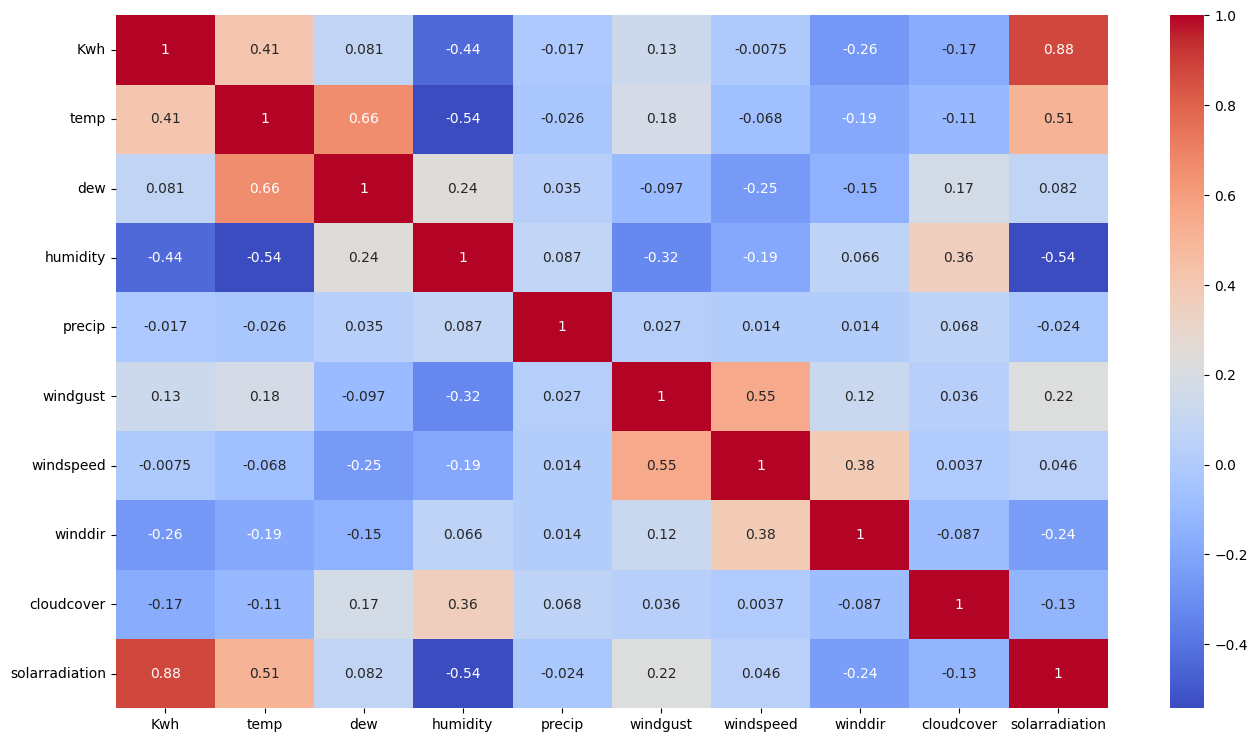

In [24]:
plt.figure(figsize= (16, 9))
sns.heatmap(tc, annot= True, cmap = "coolwarm")
plt.show()

# Temperature Forecast 

In [25]:
temperature_data = data[['dew', 'humidity', 'windgust', 'winddir', 'cloudcover', 'solarradiation', 'temp']]

In [26]:
def df_to_x_y(df, size = 24):
    df_as_np = df.to_numpy()
    x = []
    y = []
    for i in range(len(df_as_np) - size):
        row = [a for a in df_as_np[i: i+size, :6]]
        x.append(row)
        real_val = df_as_np[i + size][6]
        y.append(real_val)
    
    return np.array(x), np.array(y)


In [27]:
scaler = StandardScaler()
df_sacled_temp = scaler.fit_transform(temperature_data.iloc[:, :6])
df_sacled_temp = pd.DataFrame(df_sacled_temp)
df_sacled_temp.head(20)

,0,1,2,3,4,5
0,-0.378896,0.677822,0.402331,0.163000,-1.229211,-0.667640
1,-0.378896,0.677822,0.402331,0.590124,-1.229211,-0.667640
2,-0.378896,0.947992,0.477435,0.611443,-0.176073,-0.667640
3,-0.526349,0.912117,0.477435,0.565864,-0.250745,-0.667640
4,-0.378896,1.458657,0.402331,0.547485,-0.155474,-0.667640
5,-0.378896,1.457328,0.380872,0.574686,-0.209547,-0.667640
6,-0.378896,1.177858,0.520352,1.045183,-0.078226,-0.667640
7,-0.378896,0.677822,0.670561,0.898152,0.416156,-0.667640
8,-0.378896,0.918760,0.670561,0.898152,0.055669,-0.644949
9,-0.231443,0.924518,0.745665,0.530576,0.058244,-0.580657


In [28]:
df_sacled_temp = df_sacled_temp.reset_index(drop=True)
df_picked_temp = temperature_data.reset_index(drop=True)

df_sacled_temp = pd.concat([df_sacled_temp, df_picked_temp["temp"]], axis=1)
df_sacled_temp

,0,1,2,3,4,5,temp
0,-0.378896,0.677822,0.402331,0.163000,-1.229211,-0.667640,6.0
1,-0.378896,0.677822,0.402331,0.590124,-1.229211,-0.667640,6.0
2,-0.378896,0.947992,0.477435,0.611443,-0.176073,-0.667640,4.9
3,-0.526349,0.912117,0.477435,0.565864,-0.250745,-0.667640,4.0
4,-0.378896,1.458657,0.402331,0.547485,-0.155474,-0.667640,3.0
...,...,...,...,...,...,...,...
21978,0.800727,-0.843987,0.638373,-0.278091,0.812692,0.115206,24.0
21979,0.653274,-0.856388,0.638373,-0.331022,0.874490,-0.278108,23.0
21980,0.800727,-0.479036,-0.177047,-1.601364,0.411006,-0.633603,21.0
21981,0.948180,-0.179635,-0.219964,-1.601364,0.457355,-0.667640,20.0


In [29]:
x_temp, y_temp = df_to_x_y(df_sacled_temp, size= 24)
x_temp.shape, y_temp.shape

((21959, 24, 6), (21959,))

In [30]:
x_train_temp , y_train_temp = x_temp[:int(0.8*len(x_temp))], y_temp[: int(0.8*len(y_temp))]
x_val_temp, y_val_temp = x_temp[int(0.8*len(x_temp)): int(0.9*len(x_temp))], y_temp[int(0.8*len(y_temp)): int(0.9*len(y_temp))]
x_test_temp, y_test_temp = x_temp[int(0.9*len(x_temp)):], y_temp[int(0.9*len(y_temp)):]

x_train_temp.shape, y_train_temp.shape, x_val_temp.shape, y_val_temp.shape, x_test_temp.shape, y_test_temp.shape

((17567, 24, 6), (17567,), (2196, 24, 6), (2196,), (2196, 24, 6), (2196,))

In [3]:
checkpoint_callback = ModelCheckpoint(
    filepath='D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras',
    monitor='val_loss',
    save_best_only=True, 
    mode='min',     
    save_weights_only=False,
    verbose=1 
)

In [32]:
input_shape = (24, 6)

inputs = Input(shape=input_shape)

lstm_out = LSTM(64, return_sequences=True)(inputs)
norm_out = BatchNormalization()(lstm_out)

query = norm_out
value = norm_out

attention_out = Attention()([query, value])
dropout_out = Dropout(0.2)(attention_out)
flattened = Dense(64, activation="relu")(dropout_out)
flattened = BatchNormalization()(flattened)
flattened = GlobalAveragePooling1D()(flattened)
outputs = Dense(1, activation="relu")(flattened)

model_1 = Model(inputs=inputs, outputs=outputs)

model_1.compile(
    loss=MeanSquaredError(),
    optimizer=Adam(learning_rate=1e-3),
    metrics=[RootMeanSquaredError()]
)

model_1.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 24, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 24, 64)    │     18,176 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ lstm_1[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_1         │ (None, 24, 64)    │          0 │ batch_normalizat… │
│ (Attention)         │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 24, 64)    │          0 │ attention_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 24, 64)    │      4,160 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         65 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 22,913 (89.50 KB)

 Trainable params: 22,657 (88.50 KB)

 Non-trainable params: 256 (1.00 KB)

In [33]:
lr_schedule = ReduceLROnPlateau(
    monitor='loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

In [34]:
model_1.fit(x_train_temp, y_train_temp, 
            validation_data = (x_val_temp, y_val_temp), 
            epochs = 40,
            batch_size= 32,
            callbacks=[checkpoint_callback]
            )

Epoch 1/40
546/549 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 85.4233 - root_mean_squared_error: 8.9047
Epoch 1: val_loss improved from inf to 27.31895, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
549/549 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 85.1165 - root_mean_squared_error: 8.8878 - val_loss: 27.3190 - val_root_mean_squared_error: 5.2159
Epoch 2/40
545/549 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 19.5919 - root_mean_squared_error: 4.4252
Epoch 2: val_loss improved from 27.31895 to 23.53010, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
549/549 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 19.5937 - root_mean_squared_error: 4.4254 - val_loss: 23.5301 - val_root_mean_squared_error: 4.8449
Epoch 3/40
545/549 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 14.9871 - root_mean_squared_error: 3.8655
Epoch 3: val_loss improved from 23.53010 to 8.68513, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Disserta

In [35]:
test_predictions_temp = model_1.predict(x_test_temp).flatten()
test_results_temp = pd.DataFrame({"Val Predictions" : test_predictions_temp, "Real Data" : y_test_temp})
test_results_temp
test_results_temp.index = temperature_data.iloc[-2196:].index

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


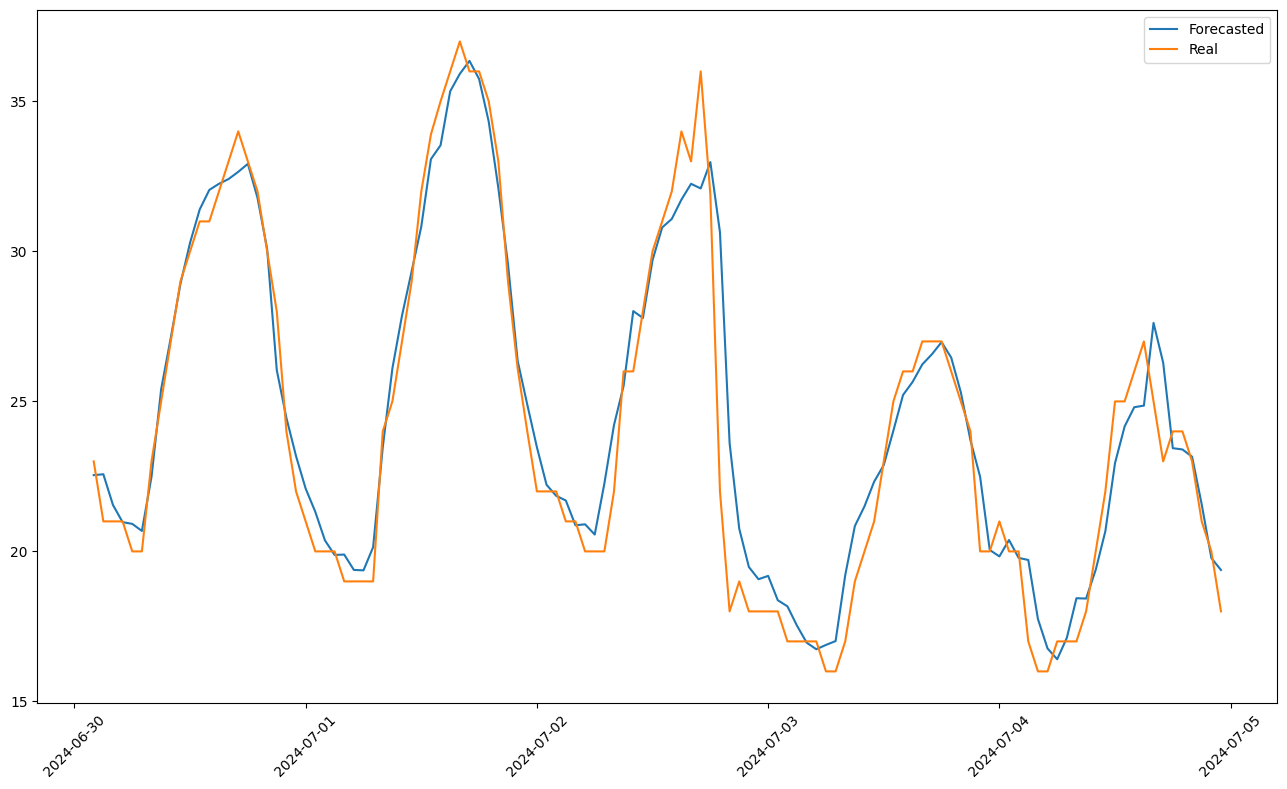

In [36]:
plt.figure(figsize= (16, 9))
plt.plot(test_results_temp["Val Predictions"][-118 :], label = "Forecasted")
plt.plot(test_results_temp["Real Data"][-118 :], label = "Real")
plt.legend()
plt.xticks(rotation = 45)
plt.show()

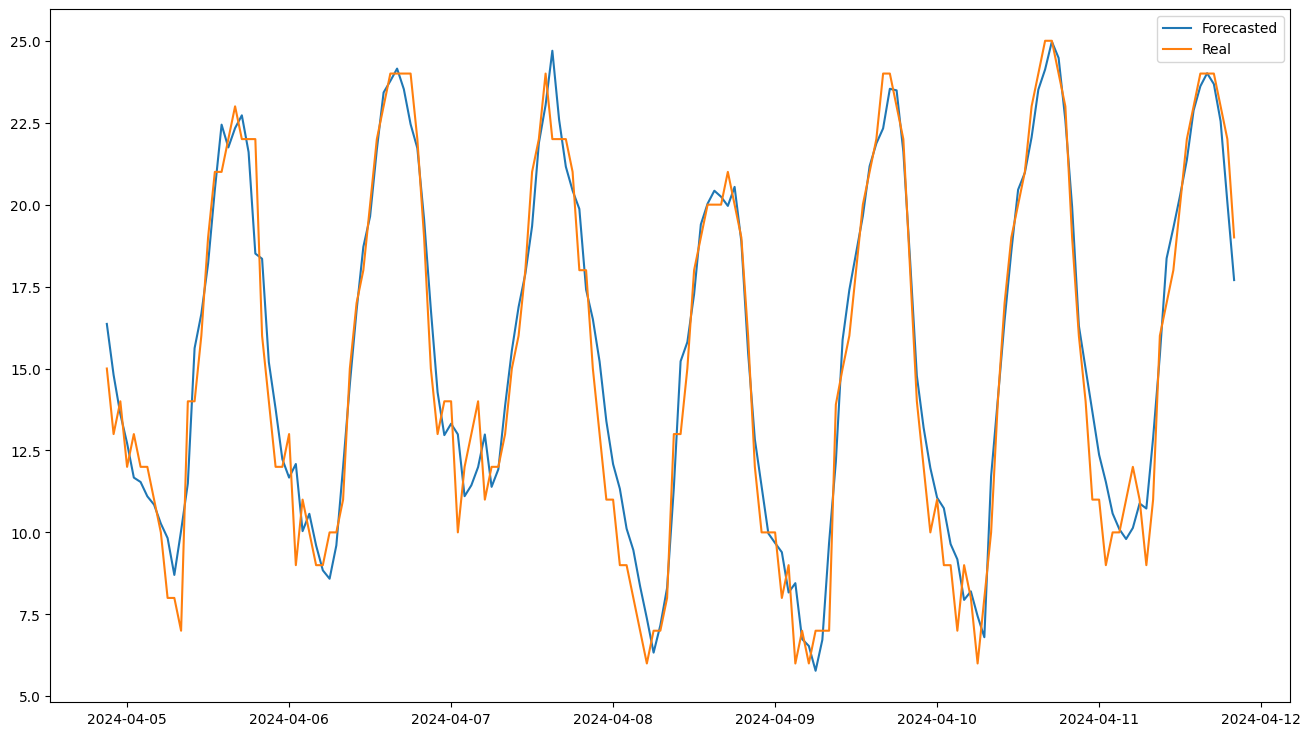

In [37]:
plt.figure(figsize= (16, 9))
plt.plot(test_results_temp["Val Predictions"][9:177], label = "Forecasted")
plt.plot(test_results_temp["Real Data"][9:177], label = "Real")
plt.legend()
plt.show()

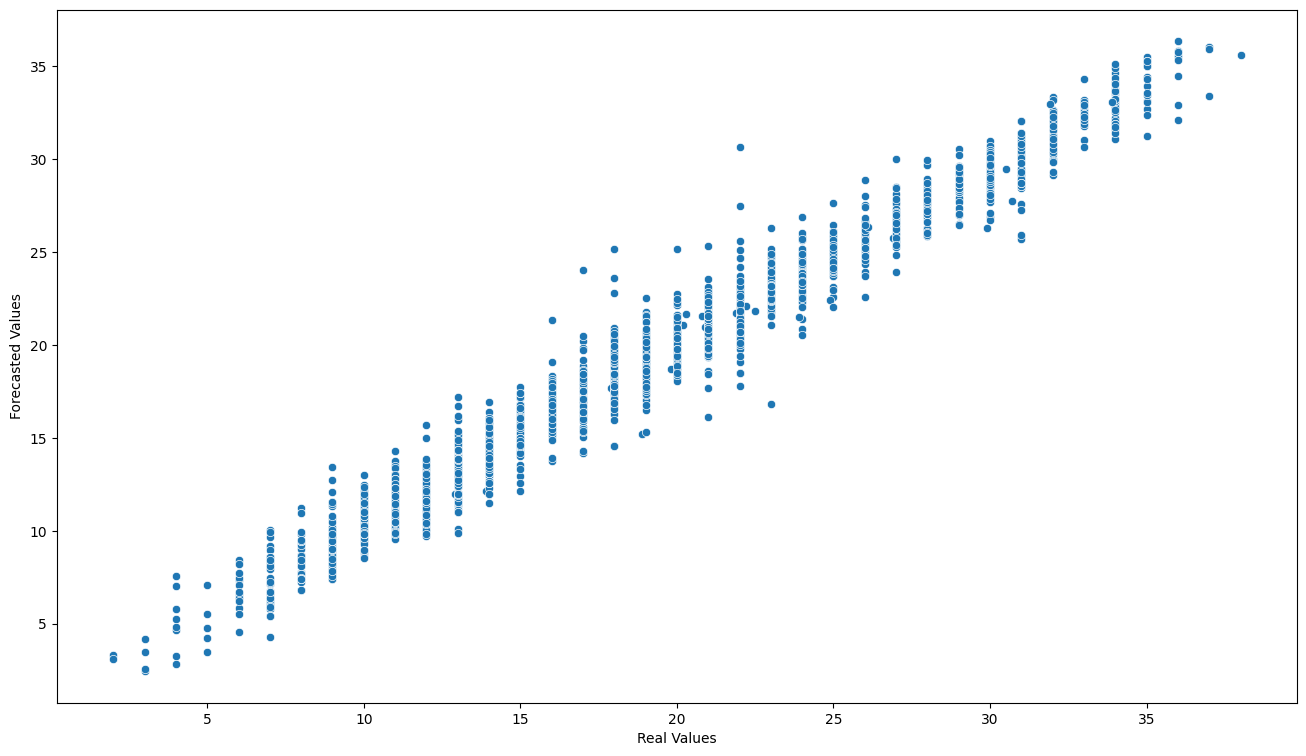

In [38]:
plt.figure(figsize= (16, 9))
sns.scatterplot(x = "Real Data", y = "Val Predictions", data = test_results_temp)
plt.xlabel("Real Values")
plt.ylabel("Forecasted Values")
plt.show()

In [39]:
mse_temp = mean_squared_error(test_results_temp["Real Data"], test_results_temp["Val Predictions"])
print(f" Mean Squared Error = {round(mse_temp, 5)} \n Root Mean Squared Error = {round(np.sqrt(mse_temp), 5)}")

ss_total = np.sum((test_results_temp["Real Data"] - test_results_temp["Real Data"].mean()) ** 2)
residual = np.sum((test_results_temp["Real Data"] - test_results_temp["Val Predictions"]) ** 2)
r_squared_temp = 1 - (residual / ss_total)

r_squared_temp ,mse_temp #0.96605

 Mean Squared Error = 1.5588 
 Root Mean Squared Error = 1.24852


(0.9693415539435227, 1.5588048936049275)

# Humidity Forecast

In [40]:
humidity_data = data[['temp', 'dew', 'windgust', 'cloudcover', 'solarradiation', 'humidity']]

In [41]:
def df_to_x_y(df, size = 24):
    df_as_np = df.to_numpy()
    x = []
    y = []
    for i in range(len(df_as_np) - size):
        row = [a for a in df_as_np[i: i+size, :5]]
        x.append(row)
        real_val = df_as_np[i + size][5]
        y.append(real_val)
    
    return np.array(x), np.array(y)


In [42]:
scaler = StandardScaler()
df_sacled_humidity = scaler.fit_transform(humidity_data.iloc[:, :5])
df_sacled_humidity = pd.DataFrame(df_sacled_humidity)
df_sacled_humidity.head(20)

,0,1,2,3,4
0,-0.844550,-0.378896,0.402331,-1.229211,-0.667640
1,-0.844550,-0.378896,0.402331,-1.229211,-0.667640
2,-0.969842,-0.378896,0.477435,-0.176073,-0.667640
3,-1.072353,-0.526349,0.477435,-0.250745,-0.667640
4,-1.186254,-0.378896,0.402331,-0.155474,-0.667640
5,-1.186254,-0.378896,0.380872,-0.209547,-0.667640
6,-1.072353,-0.378896,0.520352,-0.078226,-0.667640
7,-0.844550,-0.378896,0.670561,0.416156,-0.667640
8,-0.958452,-0.378896,0.670561,0.055669,-0.644949
9,-0.844550,-0.231443,0.745665,0.058244,-0.580657


In [43]:
df_sacled_humidity = df_sacled_humidity.reset_index(drop=True)
df_picked_humidity = humidity_data.reset_index(drop=True)

df_sacled_humidity = pd.concat([df_sacled_humidity, df_picked_humidity["humidity"]], axis=1)
df_sacled_humidity

,0,1,2,3,4,humidity
0,-0.844550,-0.378896,0.402331,-1.229211,-0.667640,75.51
1,-0.844550,-0.378896,0.402331,-1.229211,-0.667640,75.51
2,-0.969842,-0.378896,0.477435,-0.176073,-0.667640,81.61
3,-1.072353,-0.526349,0.477435,-0.250745,-0.667640,80.80
4,-1.186254,-0.378896,0.402331,-0.155474,-0.667640,93.14
...,...,...,...,...,...,...
21978,1.205675,0.800727,0.638373,0.812692,0.115206,41.15
21979,1.091774,0.653274,0.638373,0.874490,-0.278108,40.87
21980,0.863971,0.800727,-0.177047,0.411006,-0.633603,49.39
21981,0.750070,0.948180,-0.219964,0.457355,-0.667640,56.15


In [44]:
x_humidity, y_humidity = df_to_x_y(df_sacled_humidity, size= 24)
x_humidity.shape, y_humidity.shape

((21959, 24, 5), (21959,))

In [45]:
x_train_humidity, y_train_humidity = x_humidity[:int(0.8*len(x_humidity))], y_humidity[: int(0.8*len(y_humidity))]
x_val_humidity, y_val_humidity = x_humidity[int(0.8*len(x_humidity)): int(0.9*len(x_humidity))], y_humidity[int(0.8*len(y_humidity)): int(0.9*len(y_humidity))]
x_test_humidity, y_test_humidity = x_humidity[int(0.9*len(x_humidity)):], y_humidity[int(0.9*len(y_humidity)):]

x_train_humidity.shape, y_train_humidity.shape, x_val_humidity.shape, y_val_humidity.shape, x_test_humidity.shape, y_test_humidity.shape

((17567, 24, 5), (17567,), (2196, 24, 5), (2196,), (2196, 24, 5), (2196,))

In [46]:
input_shape = (24, 5)

inputs = Input(shape=input_shape)

lstm_out = LSTM(64, return_sequences=True)(inputs)
norm_out = BatchNormalization()(lstm_out)

query = norm_out
value = norm_out

attention_out = Attention()([query, value])
dropout_out = Dropout(0.2)(attention_out)
flattened = Dense(64, activation="relu")(dropout_out)
flattened = BatchNormalization()(flattened)
flattened = GlobalAveragePooling1D()(flattened)
outputs = Dense(1, activation="relu")(flattened)

model_1 = Model(inputs=inputs, outputs=outputs)

model_1.compile(
    loss=MeanSquaredError(),
    optimizer=Adam(learning_rate=1e-3),
    metrics=[RootMeanSquaredError()]
)

model_1.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 24, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 24, 64)    │     17,920 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ lstm_2[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_2         │ (None, 24, 64)    │          0 │ batch_normalizat… │
│ (Attention)         │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 24, 64)    │          0 │ attention_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 24, 64)    │      4,160 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ dense_4[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         65 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 22,657 (88.50 KB)

 Trainable params: 22,401 (87.50 KB)

 Non-trainable params: 256 (1.00 KB)

In [47]:
model_1.fit(x_train_humidity, y_train_humidity, 
            validation_data = (x_val_humidity, y_val_humidity), 
            epochs = 40,
            batch_size= 32,
            callbacks=[checkpoint_callback]
            )

Epoch 1/40
544/549 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2926.3989 - root_mean_squared_error: 53.8745
Epoch 1: val_loss did not improve from 1.80811
549/549 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 2917.7056 - root_mean_squared_error: 53.7902 - val_loss: 803.5085 - val_root_mean_squared_error: 28.3011
Epoch 2/40
544/549 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 524.9872 - root_mean_squared_error: 22.8610
Epoch 2: val_loss did not improve from 1.80811
549/549 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 523.8928 - root_mean_squared_error: 22.8364 - val_loss: 218.8777 - val_root_mean_squared_error: 14.7606
Epoch 3/40
542/549 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 208.2104 - root_mean_squared_error: 14.3477
Epoch 3: val_loss did not improve from 1.80811
549/549 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 207.2996 - root_mean_squared_error: 14.3145 - val_loss: 55.7544 - val_root_mean_squared_error: 7.4755
Epoch 4/40
549/549 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 64.2805 - root_mean_squared_

In [48]:
test_predictions_humidity = model_1.predict(x_test_humidity).flatten()
test_results_humidity = pd.DataFrame({"Val Predictions" : test_predictions_humidity, "Real Data" : y_test_humidity})
test_results_humidity
test_results_humidity.index = humidity_data.iloc[-2196:].index

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


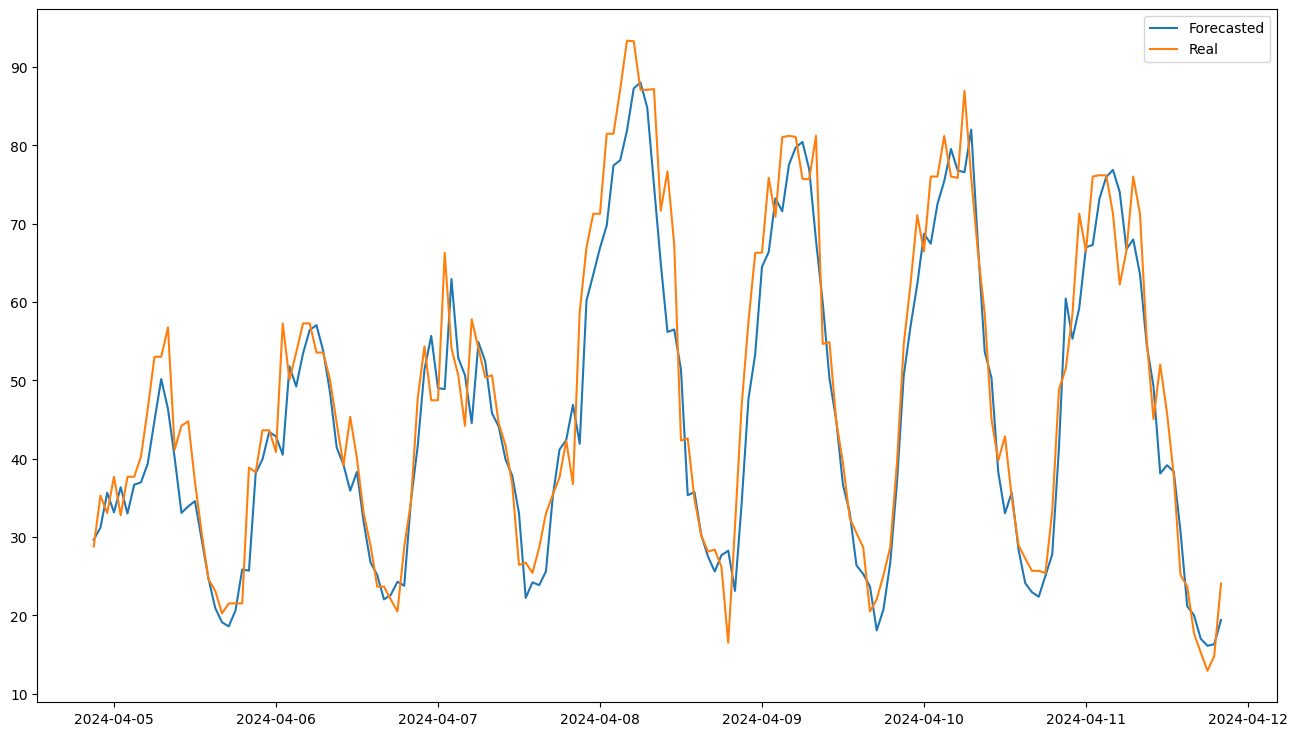

In [49]:
plt.figure(figsize= (16, 9))
plt.plot(test_results_humidity["Val Predictions"][9:177], label = "Forecasted")
plt.plot(test_results_humidity["Real Data"][9:177], label = "Real")
plt.legend()
plt.show()

In [50]:
mse_humidity = mean_squared_error(test_results_humidity["Real Data"], test_results_humidity["Val Predictions"])
print(f" Mean Squared Error = {round(mse_humidity, 5)} \n Root Mean Squared Error = {round(np.sqrt(mse_humidity), 5)}")

ss_total = np.sum((test_results_humidity["Real Data"] - test_results_humidity["Real Data"].mean()) ** 2)
residual = np.sum((test_results_humidity["Real Data"] - test_results_humidity["Val Predictions"]) ** 2)
r_squared_humidity = 1 - (residual / ss_total)

r_squared_humidity ,mse_humidity

 Mean Squared Error = 45.02777 
 Root Mean Squared Error = 6.71027


(0.9170359133141119, 45.027773013865534)

# WindGust Forecast

In [51]:
windgust_data = data[['humidity', 'windspeed', 'cloudcover', 'windgust']]

In [52]:
def df_to_x_y(df, size = 24):
    df_as_np = df.to_numpy()
    x = []
    y = []
    for i in range(len(df_as_np) - size):
        row = [a for a in df_as_np[i: i+size, :4]]
        x.append(row)
        real_val = df_as_np[i + size][4]
        y.append(real_val)
    
    return np.array(x), np.array(y)


In [53]:
scaler = StandardScaler()
df_sacled_windgust = scaler.fit_transform(windgust_data.iloc[:, :4])
df_sacled_windgust = pd.DataFrame(df_sacled_windgust)
df_sacled_windgust.head(20)

,0,1,2,3
0,0.677822,-0.044332,-1.229211,0.402331
1,0.677822,-0.397941,-1.229211,0.402331
2,0.947992,-0.044332,-0.176073,0.477435
3,0.912117,-0.687257,-0.250745,0.477435
4,1.458657,-0.397941,-0.155474,0.402331
5,1.457328,-0.687257,-0.209547,0.380872
6,1.177858,0.534300,-0.078226,0.520352
7,0.677822,0.534300,0.416156,0.670561
8,0.918760,1.096858,0.055669,0.670561
9,0.924518,0.534300,0.058244,0.745665


In [54]:
df_sacled_windgust = df_sacled_windgust.reset_index(drop=True)
df_picked_windgust = windgust_data.reset_index(drop=True)

df_sacled_windgust = pd.concat([df_sacled_windgust, df_picked_windgust["windgust"]], axis=1)
df_sacled_windgust

,0,1,2,3,windgust
0,0.677822,-0.044332,-1.229211,0.402331,19.8
1,0.677822,-0.397941,-1.229211,0.402331,19.8
2,0.947992,-0.044332,-0.176073,0.477435,20.5
3,0.912117,-0.687257,-0.250745,0.477435,20.5
4,1.458657,-0.397941,-0.155474,0.402331,19.8
...,...,...,...,...,...
21978,-0.843987,0.244984,0.812692,0.638373,22.0
21979,-0.856388,-0.687257,0.874490,0.638373,22.0
21980,-0.479036,-1.265889,0.411006,-0.177047,14.4
21981,-0.179635,-1.265889,0.457355,-0.219964,14.0


In [55]:
x_windgust, y_windgust = df_to_x_y(df_sacled_windgust, size= 24)
x_windgust.shape, y_windgust.shape

((21959, 24, 4), (21959,))

In [56]:
x_train_windgust, y_train_windgust= x_windgust[:int(0.8*len(x_windgust))], y_windgust[: int(0.8*len(y_windgust))]
x_val_windgust, y_val_windgust = x_windgust[int(0.8*len(x_windgust)): int(0.9*len(x_windgust))], y_windgust[int(0.8*len(y_windgust)): int(0.9*len(y_windgust))]
x_test_windgust, y_test_windgust = x_windgust[int(0.9*len(x_windgust)):], y_windgust[int(0.9*len(y_windgust)):]

x_train_windgust.shape, y_train_windgust.shape, x_val_windgust.shape, y_val_windgust.shape, x_test_windgust.shape, y_test_windgust.shape

((17567, 24, 4), (17567,), (2196, 24, 4), (2196,), (2196, 24, 4), (2196,))

In [57]:
input_shape = (24, 4)

inputs = Input(shape=input_shape)

lstm_out = LSTM(64, return_sequences=True)(inputs)
norm_out = BatchNormalization()(lstm_out)

query = norm_out
value = norm_out

attention_out = Attention()([query, value])
dropout_out = Dropout(0.2)(attention_out)
flattened = Dense(64, activation="relu")(dropout_out)
flattened = BatchNormalization()(flattened)
flattened = GlobalAveragePooling1D()(flattened)
outputs = Dense(1, activation="relu")(flattened)

model_1 = Model(inputs=inputs, outputs=outputs)

model_1.compile(
    loss=MeanSquaredError(),
    optimizer=Adam(learning_rate=1e-3),
    metrics=[RootMeanSquaredError()]
)

model_1.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 24, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 24, 64)    │     17,664 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ lstm_3[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_3         │ (None, 24, 64)    │          0 │ batch_normalizat… │
│ (Attention)         │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 24, 64)    │          0 │ attention_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 24, 64)    │      4,160 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ dense_6[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1)         │         65 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 22,401 (87.50 KB)

 Trainable params: 22,145 (86.50 KB)

 Non-trainable params: 256 (1.00 KB)

In [58]:
model_1.fit(x_train_windgust, y_train_windgust, 
            validation_data = (x_val_windgust, y_val_windgust), 
            epochs = 40,
            batch_size= 32,
            callbacks=[checkpoint_callback]
            )

Epoch 1/40
549/549 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 170.5801 - root_mean_squared_error: 12.9481
Epoch 1: val_loss did not improve from 1.80811
549/549 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 170.4939 - root_mean_squared_error: 12.9447 - val_loss: 88.2373 - val_root_mean_squared_error: 9.4014
Epoch 2/40
542/549 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 88.6676 - root_mean_squared_error: 9.4024
Epoch 2: val_loss did not improve from 1.80811
549/549 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 88.5262 - root_mean_squared_error: 9.3948 - val_loss: 94.3153 - val_root_mean_squared_error: 9.7059
Epoch 3/40
542/549 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 51.1362 - root_mean_squared_error: 7.1469
Epoch 3: val_loss did not improve from 1.80811
549/549 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 51.0611 - root_mean_squared_error: 7.1415 - val_loss: 47.2936 - val_root_mean_squared_error: 6.8740
Epoch 4/40
544/549 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 39.0676 - root_mean_squared_error: 6.2496


In [59]:
test_predictions_windgust = model_1.predict(x_test_windgust).flatten()
test_results_windgust = pd.DataFrame({"Val Predictions" : test_predictions_windgust, "Real Data" : y_test_windgust})
test_results_windgust
test_results_windgust.index = windgust_data.iloc[-2196:].index

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


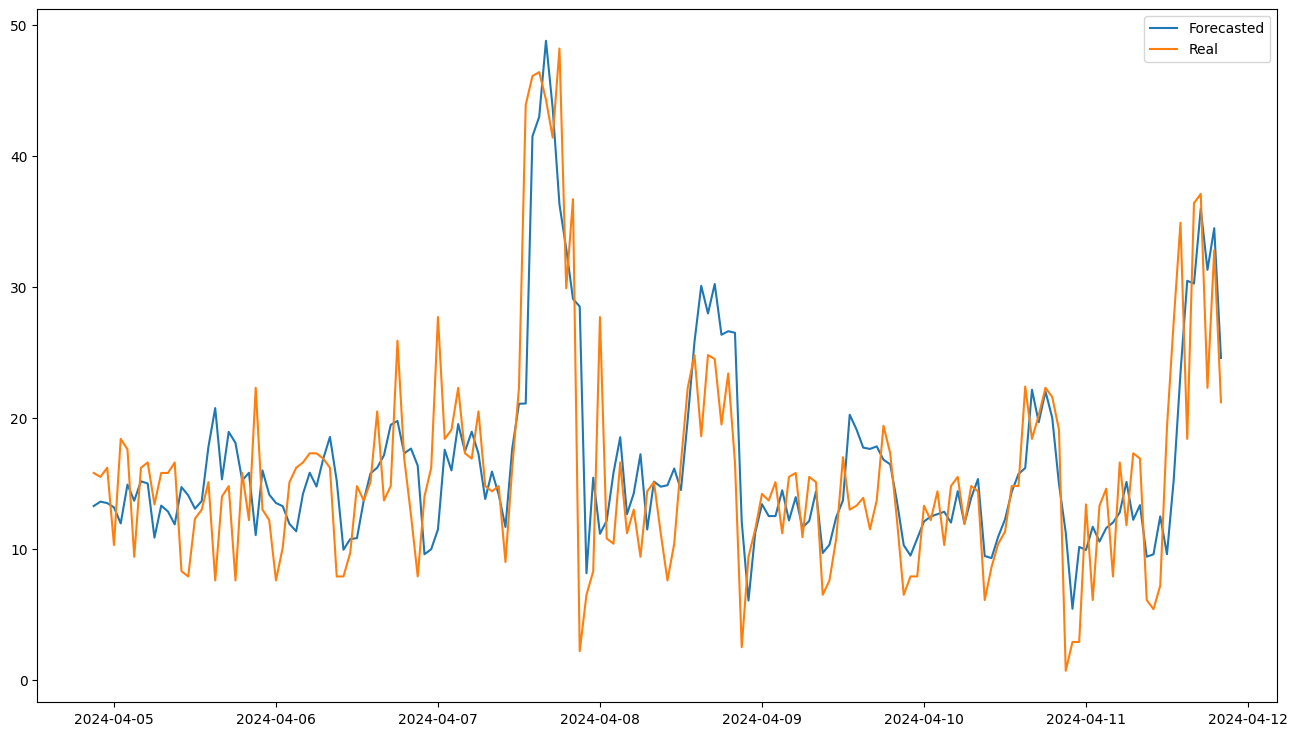

In [60]:
plt.figure(figsize= (16, 9))
plt.plot(test_results_windgust["Val Predictions"][9:177], label = "Forecasted")
plt.plot(test_results_windgust["Real Data"][9:177], label = "Real")
plt.legend()
plt.show()

In [61]:
mse_windgust = mean_squared_error(test_results_windgust["Real Data"], test_results_windgust["Val Predictions"])
print(f" Mean Squared Error = {round(mse_windgust, 5)} \n Root Mean Squared Error = {round(np.sqrt(mse_windgust), 5)}")

ss_total = np.sum((test_results_windgust["Real Data"] - test_results_windgust["Real Data"].mean()) ** 2)
residual = np.sum((test_results_windgust["Real Data"] - test_results_windgust["Val Predictions"]) ** 2)
r_squared_windgust = 1 - (residual / ss_total)

r_squared_windgust ,mse_windgust

 Mean Squared Error = 33.65541 
 Root Mean Squared Error = 5.80133


(0.606537952040739, 33.65540919048269)

# Wind Direction Forecast

In [62]:
winddir_data = data[['temp', 'windspeed', 'solarradiation', 'winddir']]

In [63]:
def df_to_x_y(df, size = 24):
    df_as_np = df.to_numpy()
    x = []
    y = []
    for i in range(len(df_as_np) - size):
        row = [a for a in df_as_np[i: i+size, :4]]
        x.append(row)
        real_val = df_as_np[i + size][4]
        y.append(real_val)
    
    return np.array(x), np.array(y)


In [64]:
scaler = StandardScaler()
df_scaled_winddir = scaler.fit_transform(winddir_data.iloc[:, :4])
df_scaled_winddir = pd.DataFrame(df_scaled_winddir)
df_scaled_winddir.head(20)


,0,1,2,3
0,-0.844550,-0.044332,-0.667640,0.163000
1,-0.844550,-0.397941,-0.667640,0.590124
2,-0.969842,-0.044332,-0.667640,0.611443
3,-1.072353,-0.687257,-0.667640,0.565864
4,-1.186254,-0.397941,-0.667640,0.547485
5,-1.186254,-0.687257,-0.667640,0.574686
6,-1.072353,0.534300,-0.667640,1.045183
7,-0.844550,0.534300,-0.667640,0.898152
8,-0.958452,1.096858,-0.644949,0.898152
9,-0.844550,0.534300,-0.580657,0.530576


In [65]:
df_scaled_winddir = df_scaled_winddir.reset_index(drop=True)
df_picked_winddir = winddir_data.reset_index(drop=True)

df_scaled_winddir = pd.concat([df_scaled_winddir, df_picked_winddir["winddir"]], axis=1)
df_scaled_winddir


,0,1,2,3,winddir
0,-0.844550,-0.044332,-0.667640,0.163000,240.0
1,-0.844550,-0.397941,-0.667640,0.590124,298.1
2,-0.969842,-0.044332,-0.667640,0.611443,301.0
3,-1.072353,-0.687257,-0.667640,0.565864,294.8
4,-1.186254,-0.397941,-0.667640,0.547485,292.3
...,...,...,...,...,...
21978,1.205675,0.244984,0.115206,-0.278091,180.0
21979,1.091774,-0.687257,-0.278108,-0.331022,172.8
21980,0.863971,-1.265889,-0.633603,-1.601364,0.0
21981,0.750070,-1.265889,-0.667640,-1.601364,0.0


In [66]:
x_winddir, y_winddir = df_to_x_y(df_scaled_winddir, size=24)
x_winddir.shape, y_winddir.shape

x_train_winddir, y_train_winddir = x_winddir[:int(0.8*len(x_winddir))], y_winddir[:int(0.8*len(y_winddir))]
x_val_winddir, y_val_winddir = x_winddir[int(0.8*len(x_winddir)):int(0.9*len(x_winddir))], y_winddir[int(0.8*len(y_winddir)):int(0.9*len(y_winddir))]
x_test_winddir, y_test_winddir = x_winddir[int(0.9*len(x_winddir)):], y_winddir[int(0.9*len(y_winddir)):]

x_train_winddir.shape, y_train_winddir.shape, x_val_winddir.shape, y_val_winddir.shape, x_test_winddir.shape, y_test_winddir.shape


((17567, 24, 4), (17567,), (2196, 24, 4), (2196,), (2196, 24, 4), (2196,))

In [67]:
input_shape = (24, 4)

inputs = Input(shape=input_shape)

lstm_out = LSTM(64, return_sequences=True)(inputs)
norm_out = BatchNormalization()(lstm_out)

query = norm_out
value = norm_out

attention_out = Attention()([query, value])
dropout_out = Dropout(0.2)(attention_out)
flattened = Dense(64, activation="relu")(dropout_out)
flattened = BatchNormalization()(flattened)
flattened = GlobalAveragePooling1D()(flattened)
outputs = Dense(1, activation="relu")(flattened)

model_1 = Model(inputs=inputs, outputs=outputs)

model_1.compile(
    loss=MeanSquaredError(),
    optimizer=Adam(learning_rate=1e-3),
    metrics=[RootMeanSquaredError()]
)

model_1.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 24, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ (None, 24, 64)    │     17,664 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ lstm_4[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_4         │ (None, 24, 64)    │          0 │ batch_normalizat… │
│ (Attention)         │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 24, 64)    │          0 │ attention_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 24, 64)    │      4,160 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ dense_8[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 1)         │         65 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 22,401 (87.50 KB)

 Trainable params: 22,145 (86.50 KB)

 Non-trainable params: 256 (1.00 KB)

In [68]:
model_1.fit(x_train_winddir, y_train_winddir, 
            validation_data=(x_val_winddir, y_val_winddir), 
            epochs=40,
            batch_size=32,
            callbacks=[checkpoint_callback]
            )


Epoch 1/40
546/549 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 62336.4336 - root_mean_squared_error: 249.6144
Epoch 1: val_loss did not improve from 1.80811
549/549 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 62301.0664 - root_mean_squared_error: 249.5426 - val_loss: 56465.7266 - val_root_mean_squared_error: 237.7138
Epoch 2/40
541/549 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 38150.8281 - root_mean_squared_error: 194.9982
Epoch 2: val_loss did not improve from 1.80811
549/549 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 38044.7812 - root_mean_squared_error: 194.7195 - val_loss: 21158.1250 - val_root_mean_squared_error: 145.2513
Epoch 3/40
541/549 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 22550.9336 - root_mean_squared_error: 150.1545
Epoch 3: val_loss did not improve from 1.80811
549/549 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 22548.3477 - root_mean_squared_error: 150.1461 - val_loss: 17742.2070 - val_root_mean_squared_error: 132.9263
Epoch 4/40
547/549 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1

In [69]:
test_predictions_winddir = model_1.predict(x_test_winddir).flatten()
test_results_winddir = pd.DataFrame({"Val Predictions": test_predictions_winddir, "Real Data": y_test_winddir})
test_results_winddir
test_results_winddir.index = winddir_data.iloc[-2196:].index


69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


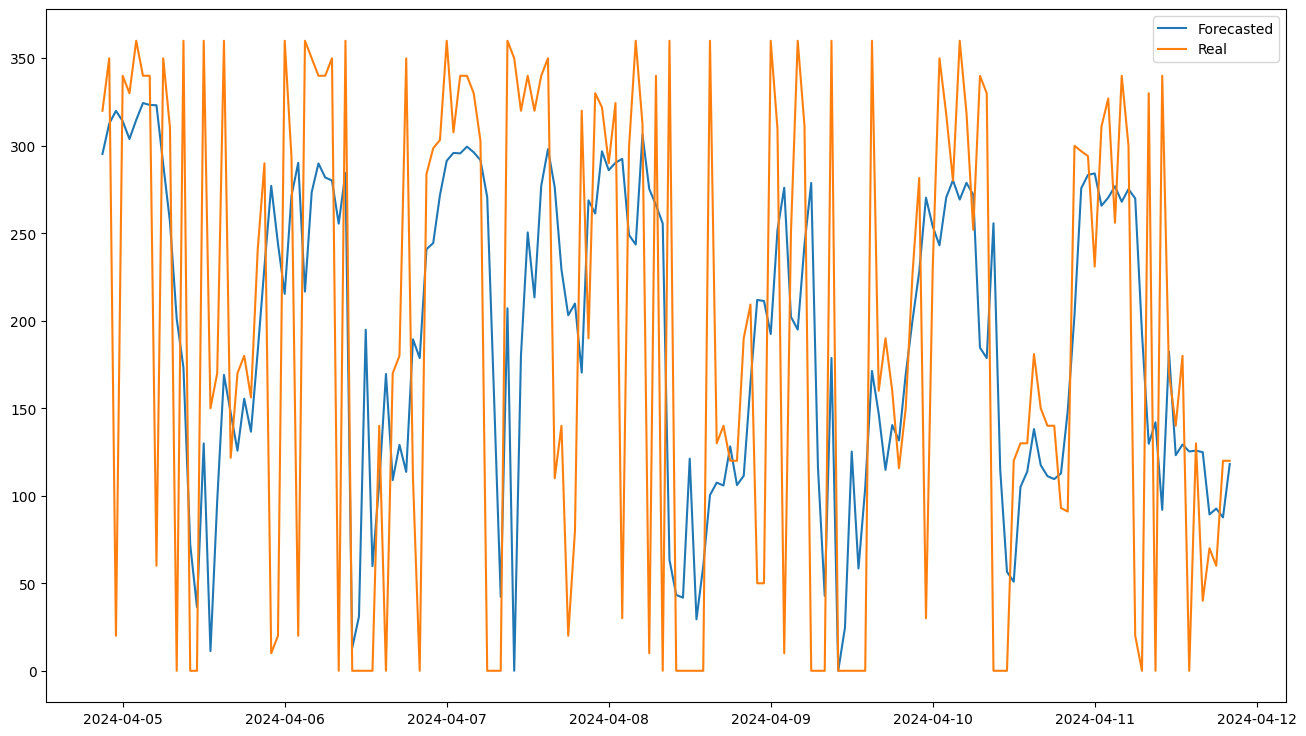

In [70]:
plt.figure(figsize=(16, 9))
plt.plot(test_results_winddir["Val Predictions"][9:177], label="Forecasted")
plt.plot(test_results_winddir["Real Data"][9:177], label="Real")
plt.legend()
plt.show()


In [71]:
mse_winddir = mean_squared_error(test_results_winddir["Real Data"], test_results_winddir["Val Predictions"])
print(f"Mean Squared Error = {round(mse_winddir, 5)} \nRoot Mean Squared Error = {round(np.sqrt(mse_winddir), 5)}")

ss_total = np.sum((test_results_winddir["Real Data"] - test_results_winddir["Real Data"].mean()) ** 2)
residual = np.sum((test_results_winddir["Real Data"] - test_results_winddir["Val Predictions"]) ** 2)
r_squared_winddir = 1 - (residual / ss_total)

r_squared_winddir, mse_winddir


Mean Squared Error = 12559.73112 
Root Mean Squared Error = 112.07021


(0.32872378120706314, 12559.731121473304)

# Cloud Cover Forecast

In [72]:
cloudcov_data = data[['humidity', 'cloudcover']]

In [73]:
def df_to_x_y(df, size = 24):
    df_as_np = df.to_numpy()
    x = []
    y = []
    for i in range(len(df_as_np) - size):
        row = [a for a in df_as_np[i: i+size, :2]]
        x.append(row)
        real_val = df_as_np[i + size][2]
        y.append(real_val)
    
    return np.array(x), np.array(y)


In [74]:
scaler = StandardScaler()
df_scaled_cloudcov = scaler.fit_transform(cloudcov_data.iloc[:, :2])
df_scaled_cloudcov = pd.DataFrame(df_scaled_cloudcov)
df_scaled_cloudcov.head(20)


,0,1
0,0.677822,-1.229211
1,0.677822,-1.229211
2,0.947992,-0.176073
3,0.912117,-0.250745
4,1.458657,-0.155474
5,1.457328,-0.209547
6,1.177858,-0.078226
7,0.677822,0.416156
8,0.918760,0.055669
9,0.924518,0.058244


In [75]:
df_scaled_cloudcov = df_scaled_cloudcov.reset_index(drop=True)
df_picked_cloudcov = cloudcov_data.reset_index(drop=True)

df_scaled_cloudcov = pd.concat([df_scaled_cloudcov, df_picked_cloudcov["cloudcover"]], axis=1)
df_scaled_cloudcov


,0,1,cloudcover
0,0.677822,-1.229211,0.0
1,0.677822,-1.229211,0.0
2,0.947992,-0.176073,40.9
3,0.912117,-0.250745,38.0
4,1.458657,-0.155474,41.7
...,...,...,...
21978,-0.843987,0.812692,79.3
21979,-0.856388,0.874490,81.7
21980,-0.479036,0.411006,63.7
21981,-0.179635,0.457355,65.5


In [76]:
x_cloudcov, y_cloudcov = df_to_x_y(df_scaled_cloudcov, size=24)
x_cloudcov.shape, y_cloudcov.shape

((21959, 24, 2), (21959,))

In [77]:
y_cloudcov

array([ 8.5,  0. ,  0. , ..., 63.7, 65.5, 68.3])

In [78]:
x_train_cloudcov, y_train_cloudcov = x_cloudcov[:int(0.8*len(x_cloudcov))], y_cloudcov[:int(0.8*len(y_cloudcov))]
x_val_cloudcov, y_val_cloudcov = x_cloudcov[int(0.8*len(x_cloudcov)):int(0.9*len(x_cloudcov))], y_cloudcov[int(0.8*len(y_cloudcov)):int(0.9*len(y_cloudcov))]
x_test_cloudcov, y_test_cloudcov = x_cloudcov[int(0.9*len(x_cloudcov)):], y_cloudcov[int(0.9*len(y_cloudcov)):]

x_train_cloudcov.shape, y_train_cloudcov.shape, x_val_cloudcov.shape, y_val_cloudcov.shape, x_test_cloudcov.shape, y_test_cloudcov.shape


((17567, 24, 2), (17567,), (2196, 24, 2), (2196,), (2196, 24, 2), (2196,))

In [79]:
input_shape = (24, 2)

inputs = Input(shape=input_shape)

lstm_out = LSTM(64, return_sequences=True)(inputs)
norm_out = BatchNormalization()(lstm_out)

query = norm_out
value = norm_out

attention_out = Attention()([query, value])
dropout_out = Dropout(0.2)(attention_out)
flattened = Dense(64, activation="relu")(dropout_out)
flattened = BatchNormalization()(flattened)
flattened = GlobalAveragePooling1D()(flattened)
outputs = Dense(1, activation="relu")(flattened)

model_1 = Model(inputs=inputs, outputs=outputs)

model_1.compile(
    loss=MeanSquaredError(),
    optimizer=Adam(learning_rate=1e-3),
    metrics=[RootMeanSquaredError()]
)

model_1.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 24, 2)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_5 (LSTM)       │ (None, 24, 64)    │     17,152 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ lstm_5[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_5         │ (None, 24, 64)    │          0 │ batch_normalizat… │
│ (Attention)         │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 24, 64)    │          0 │ attention_5[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 24, 64)    │      4,160 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ dense_10[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 1)         │         65 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 21,889 (85.50 KB)

 Trainable params: 21,633 (84.50 KB)

 Non-trainable params: 256 (1.00 KB)

In [80]:
model_1.fit(x_train_cloudcov, y_train_cloudcov, 
            validation_data=(x_val_cloudcov, y_val_cloudcov), 
            epochs=40,
            batch_size=32,
            callbacks=[checkpoint_callback]
            )

Epoch 1/40
549/549 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2602.6284 - root_mean_squared_error: 50.8227
Epoch 1: val_loss did not improve from 1.80811
549/549 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 2601.3215 - root_mean_squared_error: 50.8092 - val_loss: 775.4612 - val_root_mean_squared_error: 27.7580
Epoch 2/40
545/549 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 648.9676 - root_mean_squared_error: 25.4506
Epoch 2: val_loss did not improve from 1.80811
549/549 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 648.1498 - root_mean_squared_error: 25.4341 - val_loss: 447.9497 - val_root_mean_squared_error: 21.1122
Epoch 3/40
542/549 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 399.0114 - root_mean_squared_error: 19.9732
Epoch 3: val_loss did not improve from 1.80811
549/549 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 398.8633 - root_mean_squared_error: 19.9695 - val_loss: 501.1462 - val_root_mean_squared_error: 22.3603
Epoch 4/40
548/549 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 375.2679 - root_mean_squar

In [81]:
test_predictions_cloudcov = model_1.predict(x_test_cloudcov).flatten()
test_results_cloudcov = pd.DataFrame({"Val Predictions": test_predictions_cloudcov, "Real Data": y_test_cloudcov})
test_results_cloudcov
test_results_cloudcov.index = cloudcov_data.iloc[-2196:].index

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


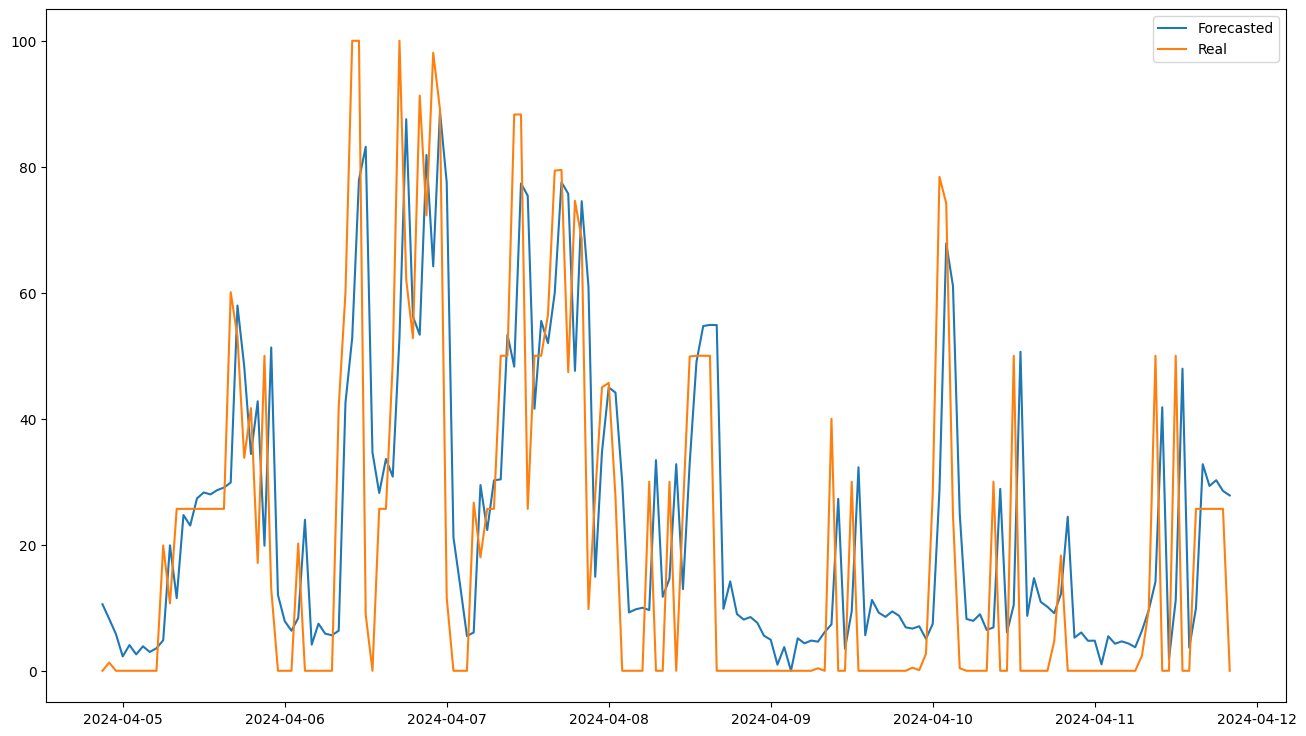

In [82]:
plt.figure(figsize=(16, 9))
plt.plot(test_results_cloudcov["Val Predictions"][9:177], label="Forecasted")
plt.plot(test_results_cloudcov["Real Data"][9:177], label="Real")
plt.legend()
plt.show()


In [83]:
mse_cloudcov = mean_squared_error(test_results_cloudcov["Real Data"], test_results_cloudcov["Val Predictions"])
print(f"Mean Squared Error = {round(mse_cloudcov, 5)} \nRoot Mean Squared Error = {round(np.sqrt(mse_cloudcov), 5)}")

ss_total = np.sum((test_results_cloudcov["Real Data"] - test_results_cloudcov["Real Data"].mean()) ** 2)
residual = np.sum((test_results_cloudcov["Real Data"] - test_results_cloudcov["Val Predictions"]) ** 2)
r_squared_cloudcov = 1 - (residual / ss_total)

r_squared_cloudcov, mse_cloudcov

Mean Squared Error = 407.65711 
Root Mean Squared Error = 20.19052


(0.7026494856198443, 407.65710867897377)

# Solar Radiation Forecast

In [21]:
solarrad_data = data[['temp', 'humidity', 'windgust', 'windspeed', 'solarradiation']]

In [85]:
def df_to_x_y(df, size = 24):
    df_as_np = df.to_numpy()
    x = []
    y = []
    for i in range(len(df_as_np) - size):
        row = [a for a in df_as_np[i: i+size, :5]]
        x.append(row)
        real_val = df_as_np[i + size][5]
        y.append(real_val)
    
    return np.array(x), np.array(y)


In [22]:
scaler = StandardScaler()
df_scaled_solarrad = scaler.fit_transform(solarrad_data.iloc[:, :5])
df_scaled_solarrad = pd.DataFrame(df_scaled_solarrad)
df_scaled_solarrad.head(20)


,0,1,2,3,4
0,-0.844550,0.677822,0.402331,-0.044332,-0.667640
1,-0.844550,0.677822,0.402331,-0.397941,-0.667640
2,-0.969842,0.947992,0.477435,-0.044332,-0.667640
3,-1.072353,0.912117,0.477435,-0.687257,-0.667640
4,-1.186254,1.458657,0.402331,-0.397941,-0.667640
5,-1.186254,1.457328,0.380872,-0.687257,-0.667640
6,-1.072353,1.177858,0.520352,0.534300,-0.667640
7,-0.844550,0.677822,0.670561,0.534300,-0.667640
8,-0.958452,0.918760,0.670561,1.096858,-0.644949
9,-0.844550,0.924518,0.745665,0.534300,-0.580657


In [23]:
df_scaled_solarrad = df_scaled_solarrad.reset_index(drop=True)
df_picked_solarrad = solarrad_data.reset_index(drop=True)

df_scaled_solarrad = pd.concat([df_scaled_solarrad, df_picked_solarrad["solarradiation"]], axis=1)
df_scaled_solarrad


,0,1,2,3,4,solarradiation
0,-0.844550,0.677822,0.402331,-0.044332,-0.667640,0.0
1,-0.844550,0.677822,0.402331,-0.397941,-0.667640,0.0
2,-0.969842,0.947992,0.477435,-0.044332,-0.667640,0.0
3,-1.072353,0.912117,0.477435,-0.687257,-0.667640,0.0
4,-1.186254,1.458657,0.402331,-0.397941,-0.667640,0.0
...,...,...,...,...,...,...
21978,1.205675,-0.843987,0.638373,0.244984,0.115206,207.0
21979,1.091774,-0.856388,0.638373,-0.687257,-0.278108,103.0
21980,0.863971,-0.479036,-0.177047,-1.265889,-0.633603,9.0
21981,0.750070,-0.179635,-0.219964,-1.265889,-0.667640,0.0


In [ ]:
x_solarrad, y_solarrad = df_to_x_y(df_scaled_solarrad, size=24)
x_solarrad.shape, y_solarrad.shape

x_train_solarrad, y_train_solarrad = x_solarrad[:int(0.8*len(x_solarrad))], y_solarrad[:int(0.8*len(y_solarrad))]
x_val_solarrad, y_val_solarrad = x_solarrad[int(0.8*len(x_solarrad)):int(0.9*len(x_solarrad))], y_solarrad[int(0.8*len(y_solarrad)):int(0.9*len(y_solarrad))]
x_test_solarrad, y_test_solarrad = x_solarrad[int(0.9*len(x_solarrad)):], y_solarrad[int(0.9*len(y_solarrad)):]

x_train_solarrad.shape, y_train_solarrad.shape, x_val_solarrad.shape, y_val_solarrad.shape, x_test_solarrad.shape, y_test_solarrad.shape


In [89]:
input_shape = (24, 5)

inputs = Input(shape=input_shape)

lstm_out = LSTM(64, return_sequences=True)(inputs)
norm_out = BatchNormalization()(lstm_out)

query = norm_out
value = norm_out

attention_out = Attention()([query, value])
dropout_out = Dropout(0.2)(attention_out)
flattened = Dense(64, activation="relu")(dropout_out)
flattened = BatchNormalization()(flattened)
flattened = GlobalAveragePooling1D()(flattened)
outputs = Dense(1, activation="relu")(flattened)

model_1 = Model(inputs=inputs, outputs=outputs)

model_1.compile(
    loss=MeanSquaredError(),
    optimizer=Adam(learning_rate=1e-3),
    metrics=[RootMeanSquaredError()]
)

model_1.summary()

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 24, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_6 (LSTM)       │ (None, 24, 64)    │     17,920 │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ lstm_6[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_6         │ (None, 24, 64)    │          0 │ batch_normalizat… │
│ (Attention)         │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 24, 64)    │          0 │ attention_6[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 24, 64)    │      4,160 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ dense_12[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 1)         │         65 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 22,657 (88.50 KB)

 Trainable params: 22,401 (87.50 KB)

 Non-trainable params: 256 (1.00 KB)

In [90]:
model_1.fit(x_train_solarrad, y_train_solarrad, 
            validation_data=(x_val_solarrad, y_val_solarrad), 
            epochs=40,
            batch_size=32,
            callbacks=[checkpoint_callback]
            )


Epoch 1/40
541/549 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 88405.1641 - root_mean_squared_error: 297.2101
Epoch 1: val_loss did not improve from 1.80811
549/549 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 88249.0078 - root_mean_squared_error: 296.9420 - val_loss: 34745.1680 - val_root_mean_squared_error: 186.3322
Epoch 2/40
541/549 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 43981.8750 - root_mean_squared_error: 209.4081
Epoch 2: val_loss did not improve from 1.80811
549/549 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 43852.6250 - root_mean_squared_error: 209.0898 - val_loss: 14099.6885 - val_root_mean_squared_error: 118.9624
Epoch 3/40
545/549 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 17951.1992 - root_mean_squared_error: 133.5586
Epoch 3: val_loss did not improve from 1.80811
549/549 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 17921.9980 - root_mean_squared_error: 133.4482 - val_loss: 14936.7197 - val_root_mean_squared_error: 122.0784
Epoch 4/40
542/549 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1

In [91]:
test_predictions_solarrad = model_1.predict(x_test_solarrad).flatten()
test_results_solarrad = pd.DataFrame({"Val Predictions": test_predictions_solarrad, "Real Data": y_test_solarrad})
test_results_solarrad
test_results_solarrad.index = solarrad_data.iloc[-2196:].index


69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


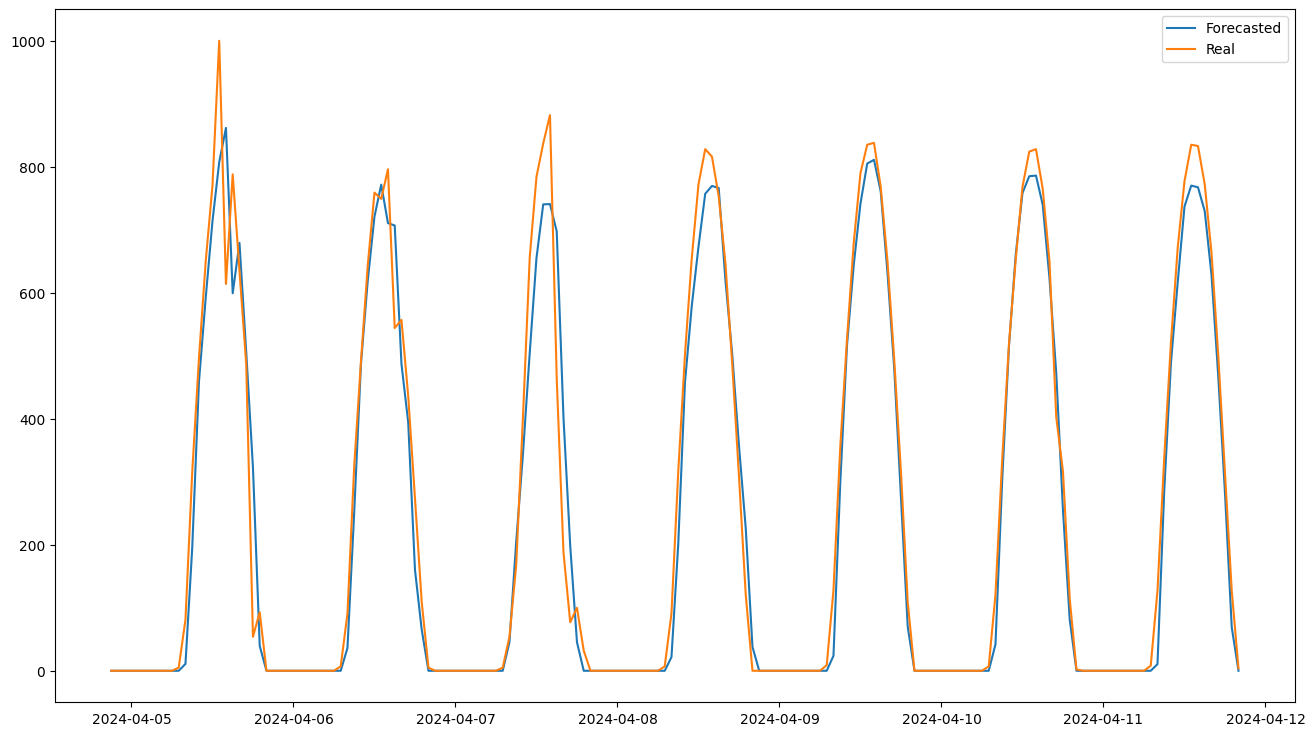

In [92]:
plt.figure(figsize=(16, 9))
plt.plot(test_results_solarrad["Val Predictions"][9:177], label="Forecasted")
plt.plot(test_results_solarrad["Real Data"][9:177], label="Real")
plt.legend()
plt.show()


In [93]:
mse_solarrad = mean_squared_error(test_results_solarrad["Real Data"], test_results_solarrad["Val Predictions"])
print(f"Mean Squared Error = {round(mse_solarrad, 5)} \nRoot Mean Squared Error = {round(np.sqrt(mse_solarrad), 5)}")

ss_total = np.sum((test_results_solarrad["Real Data"] - test_results_solarrad["Real Data"].mean()) ** 2)
residual = np.sum((test_results_solarrad["Real Data"] - test_results_solarrad["Val Predictions"]) ** 2)
r_squared_solarrad = 1 - (residual / ss_total)

r_squared_solarrad, mse_solarrad   #0.8838


Mean Squared Error = 12834.84973 
Root Mean Squared Error = 113.291


(0.8718223016803486, 12834.84973438698)

# Solar Pane Power Forecast

In [39]:
kwh_data = data[['temp', 'humidity', 'windgust', 'winddir', 'cloudcover', 'solarradiation', 'Kwh']]
kwh_data

,temp,humidity,windgust,winddir,cloudcover,solarradiation,Kwh
datetime,,,,,,,
2022-01-01 00:00:00,6.0,75.51,19.8,240.0,0.0,0.0,0.0000
2022-01-01 01:00:00,6.0,75.51,19.8,298.1,0.0,0.0,0.0000
2022-01-01 02:00:00,4.9,81.61,20.5,301.0,40.9,0.0,0.0000
2022-01-01 03:00:00,4.0,80.80,20.5,294.8,38.0,0.0,0.0000
2022-01-01 04:00:00,3.0,93.14,19.8,292.3,41.7,0.0,0.0000
...,...,...,...,...,...,...,...
2024-07-04 19:00:00,24.0,41.15,22.0,180.0,79.3,207.0,0.0592
2024-07-04 20:00:00,23.0,40.87,22.0,172.8,81.7,103.0,0.0085
2024-07-04 21:00:00,21.0,49.39,14.4,0.0,63.7,9.0,0.0000


In [40]:
def df_to_x_y(df, size = 24):
    df_as_np = df.to_numpy()
    x = []
    y = []
    for i in range(len(df_as_np) - size):
        row = [a for a in df_as_np[i: i+size, :6]]
        x.append(row)
        real_val = df_as_np[i + size][6]
        y.append(real_val)
    
    return np.array(x), np.array(y)


In [41]:
scaler = StandardScaler()
df_scaled_kwh = scaler.fit_transform(kwh_data.iloc[:, :6])
df_scaled_kwh = pd.DataFrame(df_scaled_kwh)
df_scaled_kwh.head(20)


,0,1,2,3,4,5
0,-0.844550,0.677822,0.402331,0.163000,-1.229211,-0.667640
1,-0.844550,0.677822,0.402331,0.590124,-1.229211,-0.667640
2,-0.969842,0.947992,0.477435,0.611443,-0.176073,-0.667640
3,-1.072353,0.912117,0.477435,0.565864,-0.250745,-0.667640
4,-1.186254,1.458657,0.402331,0.547485,-0.155474,-0.667640
5,-1.186254,1.457328,0.380872,0.574686,-0.209547,-0.667640
6,-1.072353,1.177858,0.520352,1.045183,-0.078226,-0.667640
7,-0.844550,0.677822,0.670561,0.898152,0.416156,-0.667640
8,-0.958452,0.918760,0.670561,0.898152,0.055669,-0.644949
9,-0.844550,0.924518,0.745665,0.530576,0.058244,-0.580657


In [42]:
df_scaled_kwh.index = data.index
df_scaled_kwh

,0,1,2,3,4,5
datetime,,,,,,
2022-01-01 00:00:00,-0.844550,0.677822,0.402331,0.163000,-1.229211,-0.667640
2022-01-01 01:00:00,-0.844550,0.677822,0.402331,0.590124,-1.229211,-0.667640
2022-01-01 02:00:00,-0.969842,0.947992,0.477435,0.611443,-0.176073,-0.667640
2022-01-01 03:00:00,-1.072353,0.912117,0.477435,0.565864,-0.250745,-0.667640
2022-01-01 04:00:00,-1.186254,1.458657,0.402331,0.547485,-0.155474,-0.667640
...,...,...,...,...,...,...
2024-07-04 19:00:00,1.205675,-0.843987,0.638373,-0.278091,0.812692,0.115206
2024-07-04 20:00:00,1.091774,-0.856388,0.638373,-0.331022,0.874490,-0.278108
2024-07-04 21:00:00,0.863971,-0.479036,-0.177047,-1.601364,0.411006,-0.633603


In [43]:
df_scaled_kwh = pd.concat([df_scaled_kwh, kwh_data["Kwh"]], axis=1)
df_scaled_kwh

,0,1,2,3,4,5,Kwh
datetime,,,,,,,
2022-01-01 00:00:00,-0.844550,0.677822,0.402331,0.163000,-1.229211,-0.667640,0.0000
2022-01-01 01:00:00,-0.844550,0.677822,0.402331,0.590124,-1.229211,-0.667640,0.0000
2022-01-01 02:00:00,-0.969842,0.947992,0.477435,0.611443,-0.176073,-0.667640,0.0000
2022-01-01 03:00:00,-1.072353,0.912117,0.477435,0.565864,-0.250745,-0.667640,0.0000
2022-01-01 04:00:00,-1.186254,1.458657,0.402331,0.547485,-0.155474,-0.667640,0.0000
...,...,...,...,...,...,...,...
2024-07-04 19:00:00,1.205675,-0.843987,0.638373,-0.278091,0.812692,0.115206,0.0592
2024-07-04 20:00:00,1.091774,-0.856388,0.638373,-0.331022,0.874490,-0.278108,0.0085
2024-07-04 21:00:00,0.863971,-0.479036,-0.177047,-1.601364,0.411006,-0.633603,0.0000


In [59]:
x_kwh, y_kwh = df_to_x_y(df_scaled_kwh, size=24)
x_kwh.shape, y_kwh.shape

x_train_kwh, y_train_kwh = x_kwh[:int(0.9*len(x_kwh))], y_kwh[:int(0.9*len(y_kwh))]
x_val_kwh, y_val_kwh = x_kwh[int(0.9*len(x_kwh)):int(0.95*len(x_kwh))], y_kwh[int(0.9*len(y_kwh)):int(0.95*len(y_kwh))]
x_test_kwh, y_test_kwh = x_kwh[int(0.95*len(x_kwh)):], y_kwh[int(0.95*len(y_kwh)):]

x_train_kwh.shape, y_train_kwh.shape, x_val_kwh.shape, y_val_kwh.shape, x_test_kwh.shape, y_test_kwh.shape

((19763, 24, 6), (19763,), (1098, 24, 6), (1098,), (1098, 24, 6), (1098,))

In [53]:
input_shape = (24, 6)

inputs = Input(shape=input_shape)

lstm_out = LSTM(64, return_sequences=True)(inputs)
norm_out = BatchNormalization()(lstm_out)

query = norm_out
value = norm_out

attention_out = Attention()([query, value])
dropout_out = Dropout(0.2)(attention_out)
flattened = Dense(64, activation="relu")(dropout_out)
flattened = BatchNormalization()(flattened)
flattened = GlobalAveragePooling1D()(flattened)
outputs = Dense(1, activation="relu")(flattened)

model_1 = Model(inputs=inputs, outputs=outputs)

model_1.compile(
    loss=MeanSquaredError(),
    optimizer=Adam(learning_rate=1e-3),
    metrics=[RootMeanSquaredError()]
)

model_1.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 24, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 24, 64)    │     18,176 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ lstm_3[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_3         │ (None, 24, 64)    │          0 │ batch_normalizat… │
│ (Attention)         │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 24, 64)    │          0 │ attention_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 24, 64)    │      4,160 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ dense_6[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1)         │         65 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 22,913 (89.50 KB)

 Trainable params: 22,657 (88.50 KB)

 Non-trainable params: 256 (1.00 KB)

In [54]:
model_1.fit(x_train_kwh, y_train_kwh, 
            validation_data=(x_val_kwh, y_val_kwh), 
            epochs=40,
            batch_size=32,
            callbacks=[checkpoint_callback]
            )


Epoch 1/40
631/632 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0554 - root_mean_squared_error: 0.2284
Epoch 1: val_loss did not improve from 0.00462
632/632 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0553 - root_mean_squared_error: 0.2283 - val_loss: 0.0223 - val_root_mean_squared_error: 0.1509
Epoch 2/40
624/632 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0132 - root_mean_squared_error: 0.1150
Epoch 2: val_loss did not improve from 0.00462
632/632 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0132 - root_mean_squared_error: 0.1149 - val_loss: 0.0178 - val_root_mean_squared_error: 0.1349
Epoch 3/40
624/632 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0098 - root_mean_squared_error: 0.0990
Epoch 3: val_loss did not improve from 0.00462
632/632 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0098 - root_mean_squared_error: 0.0990 - val_loss: 0.0120 - val_root_mean_squared_error: 0.1106
Epoch 4/40
627/632 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0082 - root_mean_squared_error: 0.0904
Epoch 4: val_l

In [56]:
test_predictions_kwh = model_1.predict(x_test_kwh).flatten()
test_results_kwh = pd.DataFrame({"Val Predictions": test_predictions_kwh, "Real Data": y_test_kwh})
test_results_kwh
test_results_kwh.index = kwh_data.iloc[-1098:].index

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


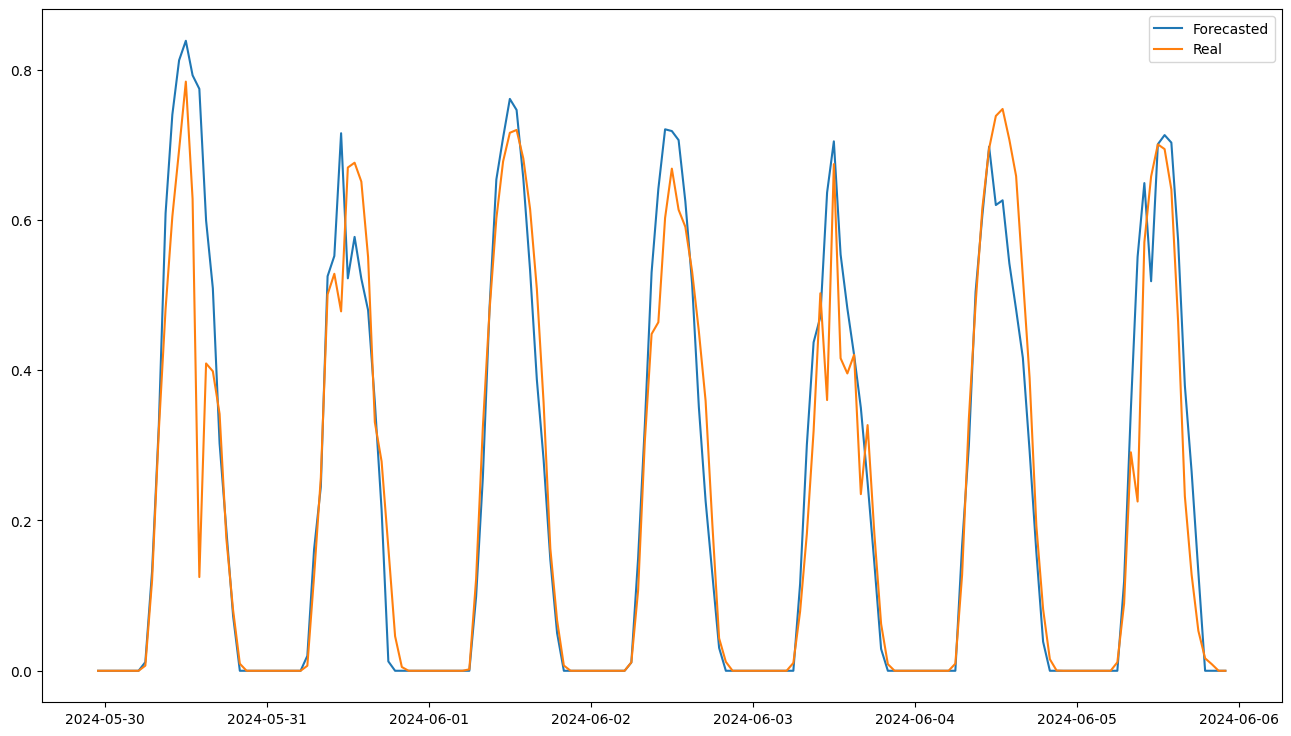

In [57]:
plt.figure(figsize=(16, 9))
plt.plot(test_results_kwh["Val Predictions"][14:182], label="Forecasted")
plt.plot(test_results_kwh["Real Data"][14:182], label="Real")
plt.legend()
plt.show()


In [58]:
mse_kwh = mean_squared_error(test_results_kwh["Real Data"], test_results_kwh["Val Predictions"])
print(f"Mean Squared Error = {round(mse_kwh, 5)} \nRoot Mean Squared Error = {round(np.sqrt(mse_kwh), 5)}")

ss_total = np.sum((test_results_kwh["Real Data"] - test_results_kwh["Real Data"].mean()) ** 2)
residual = np.sum((test_results_kwh["Real Data"] - test_results_kwh["Val Predictions"]) ** 2)
r_squared_kwh = 1 - (residual / ss_total)

r_squared_kwh, mse_kwh 

Mean Squared Error = 0.00561 
Root Mean Squared Error = 0.07491


(0.9143066819196883, 0.0056116337964251225)

# Predictions from Forecasted Values

In [129]:
weather_power_data = pd.DataFrame({'temp': test_predictions_temp, 
                                   'humidity' : test_predictions_humidity, 
                                   'windgust' : test_predictions_windgust, 
                                   'winddir' : test_predictions_winddir,
                                   'cloudcover' : test_predictions_cloudcov,
                                   'solarradiation' : test_predictions_solarrad, 
                                   'Kwh' : test_predictions_kwh})

In [127]:
weather_power_data.head()

,temperature,humidity,windgust,winddir,cloudCover,solarRad,Kwh
0,17.737242,23.815464,18.889095,225.318466,14.979159,703.990540,0.700513
1,19.631186,20.987106,20.524950,257.093109,14.339061,709.509277,0.704006
2,21.012550,19.442154,29.949768,255.933121,15.295216,729.098999,0.654244
3,21.717676,17.792183,32.642277,251.066498,14.442386,698.583984,0.582565
4,22.437052,16.850681,28.898972,243.410461,13.311343,608.711426,0.440217


In [130]:
df_scaled_forecasted = scaler.transform(weather_power_data.iloc[:, :6])
df_scaled_forecasted = pd.DataFrame(df_scaled_forecasted)
df_scaled_forecasted.head(20)

,0,1,2,3,4,5
0,0.492338,-1.611735,0.304598,0.055069,-0.843511,1.994756
1,0.708061,-1.737004,0.480112,0.288661,-0.859993,2.015628
2,0.865400,-1.805430,1.491321,0.280133,-0.835373,2.089713
3,0.945715,-1.878507,1.780206,0.244356,-0.857333,1.974310
4,1.027653,-1.920207,1.378578,0.188073,-0.886456,1.634424
5,1.106974,-1.917416,1.016967,-0.201130,-0.897824,1.125704
6,1.078488,-1.823823,0.736690,0.032680,-0.925719,0.106791
7,0.912808,-1.829581,0.750432,0.427505,-0.726110,-0.438891
8,0.601837,-1.702870,0.347188,0.540599,-0.992054,-0.667640
9,0.335592,-1.353306,-0.297596,0.569857,-0.957218,-0.667640


In [131]:
date_range = pd.date_range(start='2024/4/4 12:00:00', end='2024/7/4 23:00:00', freq='H')


weather_power_data.index = date_range

In [134]:
def df_to_x_y(df, size = 24):
    df_as_np = df.to_numpy()
    x = []
    y = []
    for i in range(len(df_as_np) - size):
        row = [a for a in df_as_np[i: i+size, :6]]
        x.append(row)
        real_val = df_as_np[i + size][5]
        y.append(real_val)
    
    return np.array(x), np.array(y)


In [135]:
x_forecast, y_forecast = df_to_x_y(df_scaled_forecasted, size=24)
x_forecast.shape, y_forecast.shape

((2172, 24, 6), (2172,))

In [136]:
forecasted_predictions = model_1.predict(x_forecast).flatten()


68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [137]:
forecasted_predictions.shape

(2172,)

<Axes: xlabel='None'>

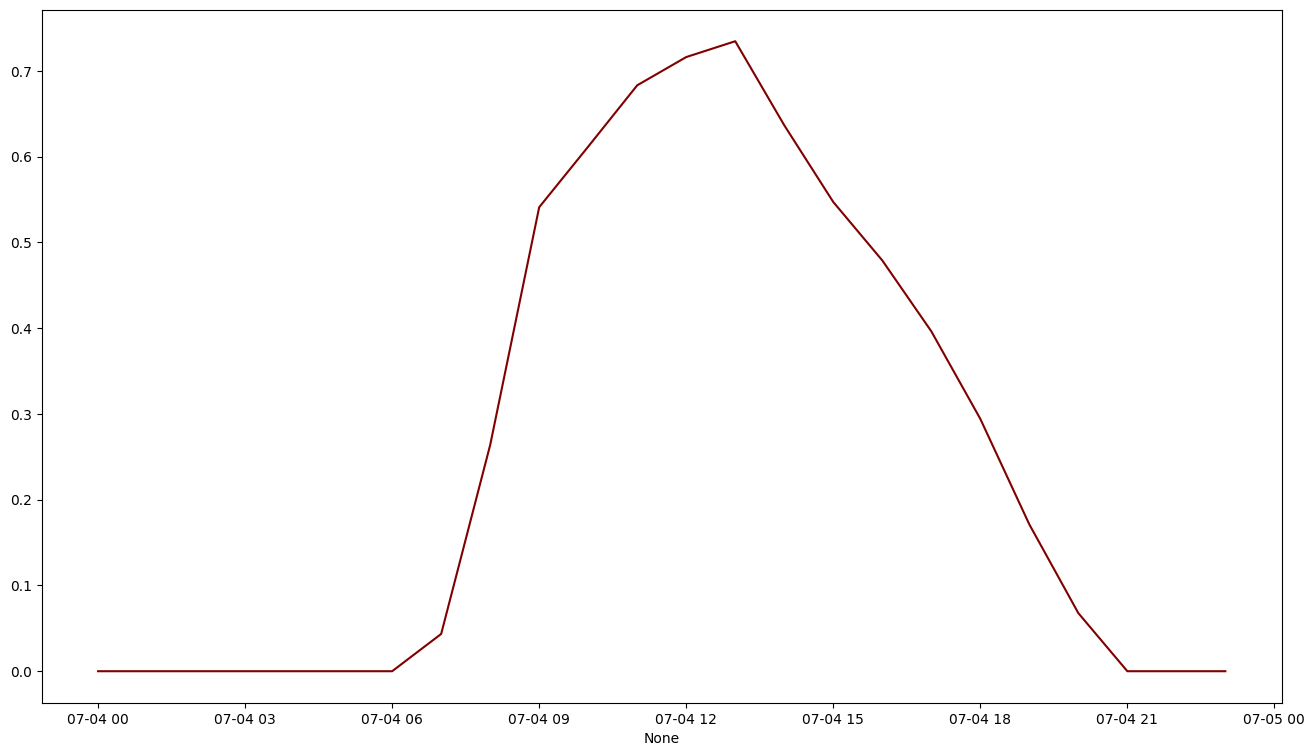

In [138]:
plt.figure(figsize= (16, 9))
sns.lineplot(x = weather_power_data.iloc[-24:].index, y= forecasted_predictions[-24 :],  color = 'Maroon', markers= 'o')

In [139]:
forecasted_predictions = pd.DataFrame(forecasted_predictions, index= date_range[-2172 :])

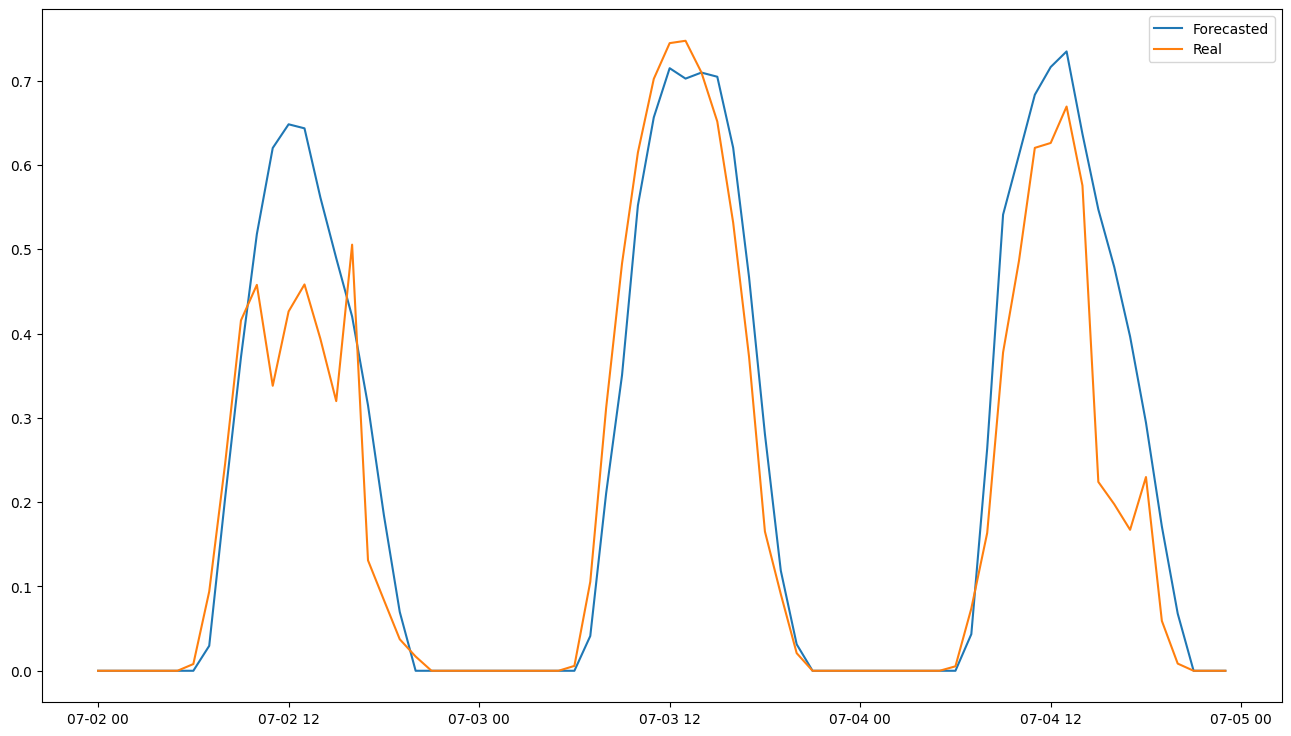

In [140]:
plt.figure(figsize=(16, 9))
plt.plot(forecasted_predictions[-72:], label="Forecasted")
plt.plot(test_results_kwh["Real Data"][-72:], label="Real")
plt.legend()
plt.show()

In [134]:
test_results_kwh["Real Data"][-72:]

datetime
2024-07-02 00:00:00    0.0000
2024-07-02 01:00:00    0.0000
2024-07-02 02:00:00    0.0000
2024-07-02 03:00:00    0.0000
2024-07-02 04:00:00    0.0000
                        ...  
2024-07-04 19:00:00    0.0592
2024-07-04 20:00:00    0.0085
2024-07-04 21:00:00    0.0000
2024-07-04 22:00:00    0.0000
2024-07-04 23:00:00    0.0000
Name: Real Data, Length: 72, dtype: float64

In [135]:
test_results_kwh["Real Data"][-72:]

datetime
2024-07-02 00:00:00    0.0000
2024-07-02 01:00:00    0.0000
2024-07-02 02:00:00    0.0000
2024-07-02 03:00:00    0.0000
2024-07-02 04:00:00    0.0000
                        ...  
2024-07-04 19:00:00    0.0592
2024-07-04 20:00:00    0.0085
2024-07-04 21:00:00    0.0000
2024-07-04 22:00:00    0.0000
2024-07-04 23:00:00    0.0000
Name: Real Data, Length: 72, dtype: float64

# For One Day Test!!

In [136]:
weather_power_data = pd.DataFrame({'Temperature': test_predictions_temp[-24:], 
                                   'Humidity' : test_predictions_humidity[-24:], 
                                   'Windgust' : test_predictions_windgust[-24:], 
                                   'Winddir' : test_predictions_winddir[-24:],
                                   'CloudCover' : test_predictions_cloudcov[-24:],
                                   'SolarRad' : test_predictions_solarrad[-24:], 
                                   'Kwh' : test_predictions_kwh[-24:]})

In [137]:
scaler = StandardScaler()
df_scaled_forecasted = scaler.fit_transform(weather_power_data.iloc[:, :7])
df_scaled_forecasted = pd.DataFrame(df_scaled_forecasted)
df_scaled_forecasted.head(20)


,0,1,2,3,4,5,6
0,-0.589497,0.505015,0.460426,1.023991,0.621568,-0.897765,-0.808958
1,-0.415466,0.007148,0.360969,0.945589,0.632592,-0.897765,-0.808958
2,-0.502873,0.148326,-0.388607,0.966470,0.688437,-0.897765,-0.808958
3,-0.505544,-0.079192,-1.135275,0.987510,0.668886,-0.897765,-0.808958
4,-1.290346,1.406106,-0.915613,0.839099,0.858512,-0.897765,-0.808958
5,-1.539509,2.017506,-1.414103,0.850239,0.762552,-0.897765,-0.808958
6,-1.529766,1.789843,-1.541264,0.902437,0.682420,-0.897765,-0.808958
7,-1.101588,1.245664,-0.972904,0.714921,0.231573,-0.805873,-0.617498
8,-0.651931,0.674710,-0.625285,0.684155,0.177994,-0.244934,-0.004415
9,-0.586555,0.488289,0.468967,0.638420,0.180723,0.233591,0.441998


In [139]:
date_range = pd.date_range(start='2024/7/4 00:00:00', end='2024/7/4 23:00:00', freq='H')


weather_power_data.index = date_range
weather_power_data

C:\Users\hercd\AppData\Local\Temp\ipykernel_8672\1421928105.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  date_range = pd.date_range(start='2024/7/4 00:00:00', end='2024/7/4 23:00:00', freq='H')


,Temperature,Humidity,Windgust,Winddir,CloudCover,SolarRad,Kwh
2024-07-04 00:00:00,19.500700,57.135048,23.012171,311.064301,91.214561,0.000000,0.000000
2024-07-04 01:00:00,20.006956,50.452141,22.484957,306.606110,91.394539,0.000000,0.000000
2024-07-04 02:00:00,19.752691,52.347179,18.511541,307.793427,92.306221,0.000000,0.000000
2024-07-04 03:00:00,19.744919,49.293190,14.553537,308.989838,91.987053,0.000000,0.000000
2024-07-04 04:00:00,17.461935,69.230461,15.717943,300.550751,95.082771,0.000000,0.000000
2024-07-04 05:00:00,16.737122,77.437332,13.075502,301.184174,93.516174,0.000000,0.000000
2024-07-04 06:00:00,16.765463,74.381386,12.401435,304.152344,92.208000,0.000000,0.000000
2024-07-04 07:00:00,18.011030,67.076828,15.414248,293.489624,84.847740,22.559843,0.046201
2024-07-04 08:00:00,19.319082,59.412880,17.256939,291.740143,83.973053,160.273346,0.194143
2024-07-04 09:00:00,19.509258,56.910526,23.057446,289.139496,84.017601,277.754059,0.301867


In [182]:
scaler = StandardScaler()
df_scaled_forecasted = scaler.fit_transform(weather_power_data.iloc[:, :7])
df_scaled_forecasted = pd.DataFrame(df_scaled_forecasted)
df_scaled_forecasted.index = date_range
df_scaled_forecasted.head(20)

,0,1,2,3,4,5,6
2024-07-04 00:00:00,-0.589497,0.505015,0.460426,1.023991,0.621568,-0.897765,-0.808958
2024-07-04 01:00:00,-0.415466,0.007148,0.360969,0.945589,0.632592,-0.897765,-0.808958
2024-07-04 02:00:00,-0.502873,0.148326,-0.388607,0.966470,0.688437,-0.897765,-0.808958
2024-07-04 03:00:00,-0.505544,-0.079192,-1.135275,0.987510,0.668886,-0.897765,-0.808958
2024-07-04 04:00:00,-1.290346,1.406106,-0.915613,0.839099,0.858512,-0.897765,-0.808958
2024-07-04 05:00:00,-1.539509,2.017506,-1.414103,0.850239,0.762552,-0.897765,-0.808958
2024-07-04 06:00:00,-1.529766,1.789843,-1.541264,0.902437,0.682420,-0.897765,-0.808958
2024-07-04 07:00:00,-1.101588,1.245664,-0.972904,0.714921,0.231573,-0.805873,-0.617498
2024-07-04 08:00:00,-0.651931,0.674710,-0.625285,0.684155,0.177994,-0.244934,-0.004415
2024-07-04 09:00:00,-0.586555,0.488289,0.468967,0.638420,0.180723,0.233591,0.441998


In [189]:
def df_to_x_y(df, size = 24):
    df_as_np = df.to_numpy()
    x = []
    y = []
    for i in range(len(df_as_np) - size + 1):
        row = [a for a in df_as_np[i: i+size, :7]]
        x.append(row)
       
    
    return np.array(x)


In [183]:
df_scaled_forecasted = pd.concat([df_scaled_forecasted, weather_power_data["Kwh"]], axis=1)
df_scaled_forecasted


,0,1,2,3,4,5,6,Kwh
2024-07-04 00:00:00,-0.589497,0.505015,0.460426,1.023991,0.621568,-0.897765,-0.808958,0.000000
2024-07-04 01:00:00,-0.415466,0.007148,0.360969,0.945589,0.632592,-0.897765,-0.808958,0.000000
2024-07-04 02:00:00,-0.502873,0.148326,-0.388607,0.966470,0.688437,-0.897765,-0.808958,0.000000
2024-07-04 03:00:00,-0.505544,-0.079192,-1.135275,0.987510,0.668886,-0.897765,-0.808958,0.000000
2024-07-04 04:00:00,-1.290346,1.406106,-0.915613,0.839099,0.858512,-0.897765,-0.808958,0.000000
2024-07-04 05:00:00,-1.539509,2.017506,-1.414103,0.850239,0.762552,-0.897765,-0.808958,0.000000
2024-07-04 06:00:00,-1.529766,1.789843,-1.541264,0.902437,0.682420,-0.897765,-0.808958,0.000000
2024-07-04 07:00:00,-1.101588,1.245664,-0.972904,0.714921,0.231573,-0.805873,-0.617498,0.046201
2024-07-04 08:00:00,-0.651931,0.674710,-0.625285,0.684155,0.177994,-0.244934,-0.004415,0.194143
2024-07-04 09:00:00,-0.586555,0.488289,0.468967,0.638420,0.180723,0.233591,0.441998,0.301867


In [190]:
x_forecast= df_to_x_y(df_scaled_forecasted, size=24)
x_forecast.shape

(1, 24, 7)

In [191]:
x_forecast

array([[[-0.5894974 ,  0.5050151 ,  0.46042636,  1.0239915 ,
          0.62156785, -0.8977645 , -0.80895823],
        [-0.41546613,  0.00714803,  0.36096868,  0.94558924,
          0.63259226, -0.8977645 , -0.80895823],
        [-0.5028725 ,  0.14832571, -0.38860682,  0.9664695 ,
          0.68843675, -0.8977645 , -0.80895823],
        [-0.5055444 , -0.07919215, -1.135275  ,  0.9875097 ,
          0.6688863 , -0.8977645 , -0.80895823],
        [-1.2903459 ,  1.4061061 , -0.91561264,  0.83909905,
          0.8585124 , -0.8977645 , -0.80895823],
        [-1.5395088 ,  2.0175064 , -1.4141029 ,  0.8502385 ,
          0.76255155, -0.8977645 , -0.80895823],
        [-1.5297662 ,  1.7898427 , -1.5412642 ,  0.9024371 ,
          0.68242025, -0.8977645 , -0.80895823],
        [-1.1015882 ,  1.2456635 , -0.9729041 ,  0.71492136,
          0.23157264, -0.8058731 , -0.6174984 ],
        [-0.6519306 ,  0.6747103 , -0.6252846 ,  0.6841548 ,
          0.17799428, -0.2449345 , -0.0044149 ],
        [-

In [249]:
forecasted_predictions = model_1.predict(x_forecast).flatten()
forecasted_predictions_df = pd.DataFrame(forecasted_predictions, index= date_range)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


In [254]:
data['Kwh'][-24:]

datetime
2024-07-04 00:00:00    0.0000
2024-07-04 01:00:00    0.0000
2024-07-04 02:00:00    0.0000
2024-07-04 03:00:00    0.0000
2024-07-04 04:00:00    0.0000
2024-07-04 05:00:00    0.0000
2024-07-04 06:00:00    0.0053
2024-07-04 07:00:00    0.0739
2024-07-04 08:00:00    0.1635
2024-07-04 09:00:00    0.3776
2024-07-04 10:00:00    0.4861
2024-07-04 11:00:00    0.6202
2024-07-04 12:00:00    0.6260
2024-07-04 13:00:00    0.6692
2024-07-04 14:00:00    0.5754
2024-07-04 15:00:00    0.2240
2024-07-04 16:00:00    0.1976
2024-07-04 17:00:00    0.1672
2024-07-04 18:00:00    0.2298
2024-07-04 19:00:00    0.0592
2024-07-04 20:00:00    0.0085
2024-07-04 21:00:00    0.0000
2024-07-04 22:00:00    0.0000
2024-07-04 23:00:00    0.0000
Name: Kwh, dtype: float64

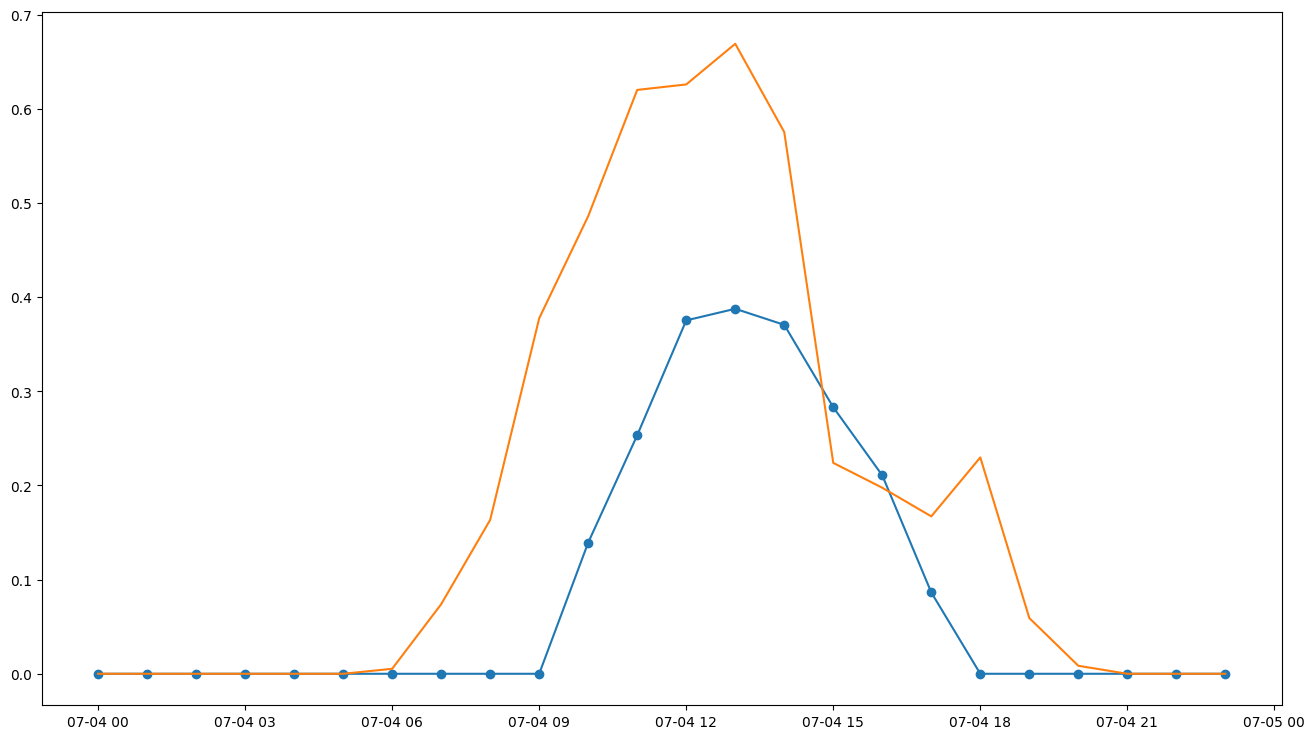

In [253]:
plt.figure(figsize= (16, 9))
plt.plot(forecasted_predictions_df, marker = 'o')
plt.plot(data['Kwh'][-24:])
plt.show()

# Multi output Test

In [234]:
def df_to_x_y(df, size = 24, steps = 24):
    df_as_np = df.to_numpy()
    x = []
    y = []
    for i in range(len(df_as_np) - size - steps + 1):
        row = [a for a in df_as_np[i: i+size, :7]]
        x.append(row)
        real_val = df_as_np[i + size: i + size + steps, 7]
        y.append(real_val)
    
    return np.array(x), np.array(y)


In [210]:
kwh_data = data[['temp', 'humidity', 'windgust', 'winddir', 'cloudcover', 'solarradiation', 'Kwh']]
kwh_data

,temp,humidity,windgust,winddir,cloudcover,solarradiation,Kwh
datetime,,,,,,,
2022-01-01 00:00:00,6.0,75.51,19.8,240.0,0.0,0.0,0.0000
2022-01-01 01:00:00,6.0,75.51,19.8,298.1,0.0,0.0,0.0000
2022-01-01 02:00:00,4.9,81.61,20.5,301.0,40.9,0.0,0.0000
2022-01-01 03:00:00,4.0,80.80,20.5,294.8,38.0,0.0,0.0000
2022-01-01 04:00:00,3.0,93.14,19.8,292.3,41.7,0.0,0.0000
...,...,...,...,...,...,...,...
2024-07-04 19:00:00,24.0,41.15,22.0,180.0,79.3,207.0,0.0592
2024-07-04 20:00:00,23.0,40.87,22.0,172.8,81.7,103.0,0.0085
2024-07-04 21:00:00,21.0,49.39,14.4,0.0,63.7,9.0,0.0000


In [235]:
scaler = StandardScaler()
df_scaled_kwh = scaler.fit_transform(kwh_data.iloc[:, :7])
df_scaled_kwh = pd.DataFrame(df_scaled_kwh)
df_scaled_kwh.head(20)


,0,1,2,3,4,5,6
0,-0.844550,0.677822,0.402331,0.163000,-1.229211,-0.667640,-0.679890
1,-0.844550,0.677822,0.402331,0.590124,-1.229211,-0.667640,-0.679890
2,-0.969842,0.947992,0.477435,0.611443,-0.176073,-0.667640,-0.679890
3,-1.072353,0.912117,0.477435,0.565864,-0.250745,-0.667640,-0.679890
4,-1.186254,1.458657,0.402331,0.547485,-0.155474,-0.667640,-0.679890
5,-1.186254,1.457328,0.380872,0.574686,-0.209547,-0.667640,-0.679890
6,-1.072353,1.177858,0.520352,1.045183,-0.078226,-0.667640,-0.679890
7,-0.844550,0.677822,0.670561,0.898152,0.416156,-0.667640,-0.679890
8,-0.958452,0.918760,0.670561,0.898152,0.055669,-0.644949,-0.542965
9,-0.844550,0.924518,0.745665,0.530576,0.058244,-0.580657,-0.234996


In [236]:
df_scaled_kwh.index = data.index

df_scaled_kwh = df_scaled_kwh.reset_index(drop=True)
df_picked_kwh = kwh_data.reset_index(drop=True)

df_scaled_kwh = pd.concat([df_scaled_kwh, df_picked_kwh["Kwh"]], axis=1)
df_scaled_kwh


,0,1,2,3,4,5,6,Kwh
0,-0.844550,0.677822,0.402331,0.163000,-1.229211,-0.667640,-0.679890,0.0000
1,-0.844550,0.677822,0.402331,0.590124,-1.229211,-0.667640,-0.679890,0.0000
2,-0.969842,0.947992,0.477435,0.611443,-0.176073,-0.667640,-0.679890,0.0000
3,-1.072353,0.912117,0.477435,0.565864,-0.250745,-0.667640,-0.679890,0.0000
4,-1.186254,1.458657,0.402331,0.547485,-0.155474,-0.667640,-0.679890,0.0000
...,...,...,...,...,...,...,...,...
21978,1.205675,-0.843987,0.638373,-0.278091,0.812692,0.115206,-0.414121,0.0592
21979,1.091774,-0.856388,0.638373,-0.331022,0.874490,-0.278108,-0.641731,0.0085
21980,0.863971,-0.479036,-0.177047,-1.601364,0.411006,-0.633603,-0.679890,0.0000
21981,0.750070,-0.179635,-0.219964,-1.601364,0.457355,-0.667640,-0.679890,0.0000


In [237]:
x_kwh, y_kwh = df_to_x_y(df_scaled_kwh, size=24)
x_kwh.shape, y_kwh.shape

x_train_kwh, y_train_kwh = x_kwh[:int(0.8*len(x_kwh))], y_kwh[:int(0.8*len(y_kwh))]
x_val_kwh, y_val_kwh = x_kwh[int(0.8*len(x_kwh)):int(0.9*len(x_kwh))], y_kwh[int(0.8*len(y_kwh)):int(0.9*len(y_kwh))]
x_test_kwh, y_test_kwh = x_kwh[int(0.9*len(x_kwh)):], y_kwh[int(0.9*len(y_kwh)):]

x_train_kwh.shape, y_train_kwh.shape, x_val_kwh.shape, y_val_kwh.shape, x_test_kwh.shape, y_test_kwh.shape

((17548, 24, 7),
 (17548, 24),
 (2194, 24, 7),
 (2194, 24),
 (2194, 24, 7),
 (2194, 24))

In [240]:
input_shape = (24, 7)

inputs = Input(shape=input_shape)

lstm_out = LSTM(64, return_sequences=True)(inputs)
norm_out = BatchNormalization()(lstm_out)

query = norm_out
value = norm_out

attention_out = Attention()([query, value])
dropout_out = Dropout(0.2)(attention_out)
flattened = Dense(64, activation="relu")(dropout_out)
flattened = BatchNormalization()(flattened)
flattened = GlobalAveragePooling1D()(flattened)
outputs = Dense(24, activation="relu")(flattened)

model_1 = Model(inputs=inputs, outputs=outputs)

model_1.compile(
    loss=MeanSquaredError(),
    optimizer=Adam(learning_rate=1e-3),
    metrics=[RootMeanSquaredError()]
)

model_1.summary()

Model: "functional_25"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12      │ (None, 24, 7)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_12 (LSTM)      │ (None, 24, 64)    │     18,432 │ input_layer_12[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ lstm_12[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_12        │ (None, 24, 64)    │          0 │ batch_normalizat… │
│ (Attention)         │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 24, 64)    │          0 │ attention_12[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 24, 64)    │      4,160 │ dropout_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ dense_24[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 24)        │      1,560 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,664 (96.34 KB)

 Trainable params: 24,408 (95.34 KB)

 Non-trainable params: 256 (1.00 KB)

In [241]:
model_1.fit(x_train_kwh, y_train_kwh, 
            validation_data=(x_val_kwh, y_val_kwh), 
            epochs=40,
            batch_size=32,
            callbacks=[checkpoint_callback]
            )


Epoch 1/40
544/549 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0512 - root_mean_squared_error: 0.2199
Epoch 1: val_loss did not improve from 0.00218
549/549 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 0.0510 - root_mean_squared_error: 0.2194 - val_loss: 0.0112 - val_root_mean_squared_error: 0.1058
Epoch 2/40
548/549 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0114 - root_mean_squared_error: 0.1070
Epoch 2: val_loss did not improve from 0.00218
549/549 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0114 - root_mean_squared_error: 0.1069 - val_loss: 0.0093 - val_root_mean_squared_error: 0.0966
Epoch 3/40
545/549 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0096 - root_mean_squared_error: 0.0979
Epoch 3: val_loss did not improve from 0.00218
549/549 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0096 - root_mean_squared_error: 0.0979 - val_loss: 0.0086 - val_root_mean_squared_error: 0.0930
Epoch 4/40
544/549 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0091 - root_mean_squared_error: 0.0951
Epoch 4: va

In [258]:
test_predictions_kwh = model_1.predict(x_test_kwh).flatten()

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [259]:
test_predictions_kwh

array([0.54811996, 0.39579567, 0.23420025, ..., 0.        , 0.        ,
       0.        ], dtype=float32)

In [260]:
y_pred_flat = test_predictions_kwh.flatten()
y_real_flat = y_test_kwh.flatten()

In [261]:
mse = mean_squared_error(y_real_flat, y_pred_flat)
ss_res = mse * len(y_real_flat)
ss_tot = ((y_real_flat - y_real_flat.mean()) ** 2).sum()
r_squared = 1 - (ss_res / ss_tot)
print(f" Our model can explain the {round(r_squared, 10)* 100}% of total variability","\n","Root Mean Squared Error = ", np.sqrt(mse))

 Our model can explain the 80.92209497% of total variability 
 Root Mean Squared Error =  0.10881626760387755
